<a href="https://colab.research.google.com/github/Emmacharleswilson/Evaluating-Demographic-Bias-in-Voice-Fraud-Detection/blob/main/Evaluating_Demographic_Bias_in_Voice_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Investigating Demographics Bias in Voice Fraud Detection

_Dissertation Project_

__Emma Charles-Wilson__

This Jupyter notebook contains the complete annotated code used in the dissertation project.

**Table of Contents:**

[Section 1](#section1): Data Creation

[Section 2](#section2): Data Post-processing

[Section 3](#section3): Visualisation of Results  

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
drive_dir = "/content/drive/My Drive/"

Mounted at /content/drive


# 1. Data Creation
<a name='section1'></a>

[a)](#section1a) Load Common Voice dataset, cloning model and spoof detection models.

[b)](#section1b) Spoof and detect script

[c)](#section1c) Generate dataset


## Load Models
<a name='section1a'></a>

The models used in this notebook require a hugging face access token. To run, update the cell below.

In [4]:
from huggingface_hub import login
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')
login(hf_token)

**Common Voice**

Common Voice is open source dataset of voices in X languages. Several of which have metadata on the speaker - age, accent, gender. The dataset also contains the prompt sentence for each speaker. Use the audio to create a custom dataset to clone each of these speakers to say standard voice security phrase, "My voice is my password". This is the dataset that will be used to test the efficacy of voice cloning detection multiples. NOTE. only used reference voices from the ENGLISH LANGUAGE subset of Common Voice, where all PHRASES ARE ENGLISH. However, some speakers are NON-NATIVE.

In [5]:
# Install and import data loading function
!pip install datasets -q
from datasets import load_dataset

# Stream Common Voice subset
cv_17 = load_dataset("mozilla-foundation/common_voice_17_0", "en", split="validated", streaming=True)

common_voice_17_0.py:   0%|          | 0.00/8.19k [00:00<?, ?B/s]

languages.py:   0%|          | 0.00/3.92k [00:00<?, ?B/s]

release_stats.py:   0%|          | 0.00/132k [00:00<?, ?B/s]

The repository for mozilla-foundation/common_voice_17_0 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/mozilla-foundation/common_voice_17_0.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


**TTS Cloning Model**

TTS is a multilingual, multi-speaker text-to-speech model from Coqui TTS used for generating natural-sounding speech in multiple languages. It supports zero-shot voice cloning, allowing it to mimic speech in a target voice using a short reference audio.


In [ ]:
# Import and import TTS libary to load cloning model
!pip install TTS -q
from TTS.api import TTS

# This is the models used for cloning speech from the reference voice
tts = TTS(model_name="tts_models/multilingual/multi-dataset/your_tts", progress_bar=False, gpu=False)

**Spoof Detection Models**
<a name='section1c'></a>

Used three benchmark spoof detection models:
> Each model outputs a prediction LABEL and a SCORE (qualifying how certain the prediction is)


>> 1. SpeechBrain
  - This makes predictions on a pair of samples
  - Evaluate TRUE if the samples are from the same speaker and FALSE if different speakers.
    - Expected label: (REF, CLONE) --> FALSE

>> 2. AST-VoxCelebSpoof
  - This makes predictions on a single sample
  - Evaluate BONAFIDE if the samples are real and SPOOF if fake
    - Expected label: REF --> BONAFIDE
    - Expected label: CLONE --> SPOOF

>> 2. AST-VoxCelebSpoof
  - This makes predictions on a single sample
  - Evaluate REAL if the samples are real and FAKE if fake
    - Expected label: REF --> REAL
    - Expected label: CLONE --> FAKE

In [ ]:
!pip install speechbrain transformers tqdm -q

from speechbrain.pretrained import SpeakerRecognition # Import for loading SpeechBrain model
from transformers import pipeline                     # Import loading AST and Deepfake pipelines

# Loads open-source spoof detection models (needs paired data)
sb = SpeakerRecognition.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir="tmp_model")

# Loads open-source spoof detection models (needs reference)
ast_pipe = pipeline("audio-classification", model="MattyB95/AST-VoxCelebSpoof-Synthetic-Voice-Detection")
df_pipe = pipeline("audio-classification", model="MelodyMachine/Deepfake-audio-detection-V2")

## Spoof and Detect Script
<a name='section1b'></a>

2) The "My voice is my password" dataset is stored on Google Drive in the folder "cloned_audio". This also contains .csv which stores the metadata for each audio file:
- ref_filename -> file name from Common Voice 17 dataset
- ref_sentence -> the English sentence recorded by each Common Voice speaker
- clone_filename -> name of "My voice is my password" audiofile
- age --> age metadata from Common Voice 17
- gender --> gender metadata from Common Voice 17
- accent --> accent metadata from Common Voice 17

NOTE. Common Voice METADATA (age, gender, accent) is not available for all files in the dataset. Only used VALIDATED audio with AT LEAST ONE KNOWN METADATA CATEGORY (see Common Voice for technical meaning of VALIDATED)

In [ ]:
import os
from scipy.signal import resample
from scipy.io.wavfile import write as write_wav
from tempfile import NamedTemporaryFile

def spoof_and_detect(voice_sample, output_dir, desired_sr=16000):
    try:
        # Load the reference audio and sampling rate from Common Voice
        ref_audio_array = voice_sample["audio"]["array"]
        ref_sr = voice_sample["audio"]["sampling_rate"]

        # Resample audio to the sampling rate that is compatible with cloning and detection models (16kHz)
        if ref_sr != desired_sr:
            duration = ref_audio_array.shape[0] / ref_sr
            num_samples = int(duration * desired_sr)
            ref_audio_array = resample(ref_audio_array, num_samples)
            ref_sr = desired_sr

        # Get the reference filepath from Common Voice
        ref_path = voice_sample["path"]

        # Remove .mp3 extension from Common Voice filepath
        ref_filename = os.path.splitext(ref_path)[0]

        # Create a file path for the cloned audio to match Common Voice filepath
        clone_path = os.path.join(output_dir, f"{ref_filename}.wav")
        os.makedirs(os.path.dirname(clone_path), exist_ok=True)  # Create directories if not exists

        # Create a temporary file for reference audio (delete=False to keep the file after closing)
        with NamedTemporaryFile(suffix=".wav", mode='wb', delete=False) as ref_wav:
            # Write reference wav to the temporary file
            ref_temp_path = ref_wav.name
            write_wav(ref_temp_path, ref_sr, ref_audio_array.astype("float32"))

        # Perform voice cloning on reference audio
        tts.tts_to_file(
            text="My voice is my password.",
            speaker_wav=ref_temp_path,
            file_path=clone_path,
            language="en"
        )

        # Compute SpeechBrain prediction from REFERENCE and CLONE
        sb_score, sb_label = sb.verify_files(ref_temp_path, clone_path)

        # Compute AST prediction from REFERENCE
        ast_ref_results = ast_pipe(ref_temp_path)
        ast_ref_score = ast_ref_results[0]["score"] if ast_ref_results else "Error"
        ast_ref_label = ast_ref_results[0]["label"] if ast_ref_results else "Error"

        # Compute AST prediction from CLONE
        ast_clone_results = ast_pipe(clone_path)
        ast_clone_score = ast_clone_results[0]["score"] if ast_clone_results else "Error"
        ast_clone_label = ast_clone_results[0]["label"] if ast_clone_results else "Error"

        # Compute Deepfake prediction from REFERENCE
        df_ref_results = df_pipe(ref_temp_path)
        df_ref_score = df_ref_results[0]["score"] if df_ref_results else "Error"
        df_ref_label = df_ref_results[0]["label"] if df_ref_results else "Error"

        # Compute Deepfake prediction from CLONE
        df_clone_results = df_pipe(clone_path)
        df_clone_score = df_clone_results[0]["score"] if df_clone_results else "Error"
        df_clone_label = df_clone_results[0]["label"] if df_clone_results else "Error"

        return {
            "ref_filepath": ref_filename,
            "ref_sentence": voice_sample["sentence"],
            "age": voice_sample["age"],
            "gender": voice_sample["gender"],
            "accent": voice_sample["accent"],
            "sb_score": sb_score.item(),
            "sb_label": sb_label.item(),
            "ast_ref_score": ast_ref_score,
            "ast_ref_label": ast_ref_label,
            "ast_clone_score": ast_clone_score,
            "ast_clone_label": ast_clone_label,
            "df_ref_score": df_ref_score,
            "df_ref_label": df_ref_label,
            "df_clone_score": df_clone_score,
            "df_clone_label": df_clone_label,
        }

    except Exception as e:
        print(f"Error processing {ref_path}: {e}")
        return {"error": str(e)}

## Generate Data
<a name='section1c'></a>



In [ ]:
from tqdm import tqdm
import pandas as pd

# Load Common Voice streaming dataset
stream = iter(cv_17)

# Define output directory to save results
output_dir = os.path.join(drive_dir, "cloned_audio_v2")
os.makedirs(os.path.dirname(output_dir), exist_ok=True)  # Create directory if not exists

batch_results = []
batch_size = 10 # Set small batch size for memory management
batch_index = 1

for voice_sample in tqdm(stream, desc="Streaming Common Voice"):
    # Only include voice_sample with at least one known metadata label
    if all(not voice_sample.get(field) or str(voice_sample.get(field)).strip() == "" for field in ["age", "gender", "accent"]):
        continue

    # Perform cloning and spoof detection and save results to list
    result = spoof_and_detect(voice_sample, output_dir)
    if result:
        batch_results.append(result)

    # Save batch results to .CSV file in drive
    if len(batch_results) >= batch_size:
        df = pd.DataFrame(batch_results) # Convert list to dataframe
        batch_path = os.path.join(output_dir, f"spoof_results_batch_{batch_index}.csv")
        df.to_csv(batch_path, index=False)

        # Reset batch variables after saving
        batch_results.clear()
        batch_index += 1

    # Save any remaining results after loop ends
    if results:
        df = pd.DataFrame(batch_results)
        batch_path = os.path.join(output_dir, f"spoof_results_batch_{batch_index}.csv")
        df.to_csv(batch_path, index=False)

    print("✅ Processing complete.")


Compile batch results into a single CSV file

In [ ]:
import glob

def compile_batch_results(data_dir, results_path):
    """
    Function used to compile all batch CSV files into one CSV file
    """
    # Find all batch CSV filepath
    batch_files = glob.glob(os.path.join(data_dir, "spoof_results_batch_*.csv"))

    # Load all batch files into one dataframe
    df = pd.concat([pd.read_csv(file) for file in batch_files], ignore_index=True)

    # Write the combined dataframe to a new CSV file in Drive
    df.to_csv(results_path, index=False)

    # Delete the batch CSV files from the Drive folder
    for file in batch_files:
        os.remove(file)
    print(f"Combined file saved and {len(batch_files)} batch files deleted.")

    return df

## UNCOMMENT TO EXECUTE
# df = compile_batch_results(data_dir, results_path)

# 2. Data Post-Processing
<a name='section2'></a>

[a)](#section2a) Standardise the format of prediction labels and gender metadata and extract word count

[b)](#section2b) Extract geographic markers from accent metadata

In [ ]:
import os
import pandas as pd

# Initialise filepath for cloned audio
data_dir = os.path.join(drive_dir, "cloned_audio_v2")
results_path = os.path.join(data_dir, "spoof_results.csv")

# Load results CSV into dataframe
df = pd.read_csv(results_path)

Function to visualise number of unique values for a given column, useful to assess the distribution of metadata labels

In [ ]:
from IPython.display import display, HTML

def view_value_counts(df, column_name):
    counts = df[column_name].value_counts()
    display(HTML(f"<div style='height:300px; overflow:auto; border:1px solid #ccc'>{counts.to_frame().to_html()}</div>"))

## Standardise labels
<a name='section2a'></a>

In [ ]:
def normalize_labels(df)
    """
    Function used to standardize the format of spoof detections predictions
    """
    # Reformat SpeechBrain predictions from (TRUE/FALSE) to (True/False)
    df['sb_label'] = df['sb_label'].replace({
        'TRUE': 'True',
        'FALSE': 'False',
    })

    # Reformat both AST predictions from (Bonafide/Spoof) to (Real/Fake)
    df['ast_ref_label'] = df['ast_ref_label'].replace({
        'Bonafide': 'Real',
        'Spoof': 'Fake',
    })

    df['ast_clone_label'] = df['ast_clone_label'].replace({
        'Bonafide': 'Real',
        'Spoof': 'Fake',
    })

    # Reformat Deepfake predictions from (real/fake) to (Real/Fake)
    df['df_ref_label'] = df['df_ref_label'].replace({
        'real': 'Real',
        'fake': 'Fake',
    })

    df['df_clone_label'] = df['df_clone_label'].replace({
        'real': 'Real',
        'fake': 'Fake',
    })

    df['gender'] = df['gender'].replace({
        'male_masculine': 'M',
        'female_feminine': 'F',
        'transgender': 'T'
    })

    df['age'] = df['age'].replace({
        'twenties': '20s',
        'thirties': '30s',
        'fourties': '40s',
        'fifties': '50s',
        'sixties': '60s',
        'seventies': '70s',
        'eighties': '80s',
        'nineties': '90s'
    })

    return df

def count_words(text):
    # Check if the reference sentence is empty or NaN
    if pd.isna(text) or not isinstance(text, str):
        return 0
    words = re.findall(r'\b\w+\b', text)
    return len(words)


## UNCOMMENT TO EXECUTE
# df = normalize_labels(df)
# df['word_count'] = df['ref_sentence'].apply(count_words)

## Extract accent features
<a name='section2c'></a>

The format of the user-input accent entries varies hugely so converting to geographic markers is an NLP task. To motivate our algorithm, qualitatively analyse all unique accent inputs in the cell below.

In [ ]:
view_value_counts(df, "accent")

,count
accent,
United States English,20037
"India and South Asia (India, Pakistan, Sri Lanka)",5784
England English,5780
Canadian English,2167
Australian English,1527
"Southern African (South Africa, Zimbabwe, Namibia)",717
Irish English,496
New Zealand English,391
Scottish English,382


**1. Preprocessing Notes**
- Translate the few non-English language entries
- Remove the word "English" that redundantly appears in must entries and random characters like "_"
- Several grouped entries "e.g. India and South Asia (India, Pakistan, Sri Lanka)" likely due to selectable inputs.
  - Remove subbrackets inputs from entries for simplicity
  - Simplify group name where appropriate: India and South Asia --> South Asia

**2. Extraction Notes**
- Use NLP processor to identify geographical information
- Most entries contain a country, city, and/or regional marker
- Geographical markers may be place names or denomyms (e.g. India or Indian)
- Geographical markers can be described by multiple place names / denonyms (e.g. British/England/UK)
- Some more specific dialect (e.g. Scouse/Glaswegian)
- Spelling errors / ambigiuities into some entries may limit NLP efficacy (e.g. Mancunion v. Mancunian, Anglosax)


### 1. Preprocessing

In [ ]:
!pip install deep_translator langid -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.4 MB/s eta 0:00:00


In [ ]:
import re
import langid # Import for detecting language from text
from deep_translator import GoogleTranslator

def detect_language(text):
    # Use langid to predict the text is English language
    langid.set_languages(['en']) # Set to English only
    lang_code, confidence = langid.classify(text)

    # If confidence is low, use langauge to check all language
    if confidence < -50:

        # Rank predictions for all langauges in order of confidence score
        langid.set_languages(None)
        predictions = langid.rank(text)

        # Langid often misclassifies English (en) and Italian (it)
        # If so a check is made to see if the top 2 are English
        if predictions[0][0] != "en" and predictions[1][0] != "en":
            lang_code = predictions[0][0]

    return lang_code

def preprocess_accent(entry, lang_code):
    # Skip empty entries
    if not isinstance(entry, str):
        return entry

    # Translate the text if non-English input detected
    if lang_code != "en":
        entry = GoogleTranslator(source='auto', target='en').translate(entry)

    # Remove subbracketed entries
    cleaned = re.sub(r'\s*\([^)]*\)', '', entry)

    # Remove the word 'english' from all parts
    cleaned = re.sub(r'\benglish\b', '', cleaned, flags=re.IGNORECASE).strip()

    # Remove the word 'accent' from all parts
    cleaned = re.sub(r'\baccent\b', '', cleaned, flags=re.IGNORECASE).strip()

    # Remove underscores if entries include this
    cleaned = cleaned.replace('_', ' ')
    cleaned = cleaned.replace('/', ',')

    # Simplifying naming for popular grouping
    cleaned = cleaned.replace('West Indies and Bermuda', 'West Indies')
    cleaned = cleaned.replace('India and South Asia', 'South Asia')

    # Split on commas and strip extra whitespace
    preprocessed = [part.strip() for part in cleaned.split(',') if part.strip()]

    return preprocessed


A handful of non-English language entries were identified. This will be translated in preprocessing

In [ ]:
# df['lang_code'] = df['accent'].map(lambda x: detect_language(x) if isinstance(x, str) else None)
df['lang_code'].unique()

The cell below shows the preprocessed accent data which will use to extract geographical features

In [ ]:
df['accent_parts'] = df.apply(lambda row: preprocess_accent(row['accent'], row['lang_code']), axis=1)
view_value_counts(df, "accent_parts")

,count
accent_parts,
[United States],20037
[South Asia],5785
[England],5780
[Canadian],2167
[Australian],1527
[Southern African],717
[Irish],497
[New Zealand],391
[Scottish],382


### 2. Feature Extraction



**Spacy NER**

SpaCy’s named entity recognition (NER) model identifies real-world objects in text, such as people, places, organizations, and dates. It uses machine learning to label spans of text with predefined entity types like GPE for geopolitical entities or NORP for nationalities. The most advanced version, en_core_web_trf, leverages transformer architectures for highly accurate, context-aware predictions.

use this model extract the following entity types from the preprocessed accents:
- GPE:         Countries, cities, states.
- LOC:         Non-GPE locations, mountain ranges
- NORP:        Nationalities or religious or political groups (issue-didn't pick up all nationalities, only way to check is manually)
- PERSON:      People, including fictional and other identies.


In [ ]:
df.drop(columns=["filtered_entries", "filtered_entites", "geographical_markers", "Unnamed: 0"])

,ref_filepath,ref_sentence,age,gender,accent,sb_score,sb_label,ast_ref_score,ast_ref_label,ast_clone_score,...,df_ref_label,df_clone_score,df_clone_label,word_count,lang_code,accent_parts,named_entities,mapped_entities,filtered_entities,accent_labels
0,en_validated_5/common_voice_en_35345007,Multiplicative inverses can be defined over ma...,fourties,M,United States English,0.524200,True,1.0,Real,1.0,...,Real,0.999982,Real,13,en,['United States'],"[('united states', 'GPE')]","[('United States', 'GPE')]",None,['United States']
1,en_validated_5/common_voice_en_17276609,Voyager One has left our solar system.,teens,M,England English,0.246618,False,1.0,Real,1.0,...,Real,0.999853,Real,7,en,['England'],"[('england', 'GPE')]","[('England', 'GPE')]",None,['England']
2,en_validated_5/common_voice_en_17276610,"Suddenly, Kimberly had an idea.",teens,M,England English,0.277756,True,1.0,Real,1.0,...,Fake,0.999983,Real,5,en,['England'],"[('england', 'GPE')]","[('England', 'GPE')]",None,['England']
3,en_validated_5/common_voice_en_17276611,How do you know?,teens,M,England English,0.220175,False,1.0,Fake,1.0,...,Fake,0.999954,Fake,4,en,['England'],"[('england', 'GPE')]","[('England', 'GPE')]",None,['England']
4,en_validated_5/common_voice_en_17276612,"I want my garden to be filled with roses, petu...",teens,M,England English,0.347754,True,1.0,Real,1.0,...,Fake,0.999981,Real,13,en,['England'],"[('england', 'GPE')]","[('England', 'GPE')]",None,['England']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59805,en_validated_1/common_voice_en_17520391,"In the discotheque, the DJ played progressive ...",teens,M,"India and South Asia (India, Pakistan, Sri Lanka)",0.183501,False,1.0,Real,1.0,...,Fake,0.999209,Real,11,en,['South Asia'],"[('south asia', 'LOC')]","[('South Asia', 'GPE')]",None,['South Asia']
59806,en_validated_1/common_voice_en_17520392,What's up homies?,teens,M,"India and South Asia (India, Pakistan, Sri Lanka)",0.149323,False,1.0,Real,1.0,...,Fake,0.999982,Real,4,en,['South Asia'],"[('south asia', 'LOC')]","[('South Asia', 'GPE')]",None,['South Asia']
59807,en_validated_1/common_voice_en_17520393,Why can't this researcher check your facts?,teens,M,"India and South Asia (India, Pakistan, Sri Lanka)",0.081524,False,1.0,Real,1.0,...,Fake,0.992913,Real,8,en,['South Asia'],"[('south asia', 'LOC')]","[('South Asia', 'GPE')]",None,['South Asia']
59808,en_validated_1/common_voice_en_38567196,The taxonomic classification of this family is...,teens,M,NaN,0.388813,True,1.0,Real,1.0,...,Real,0.999946,Fake,9,NaN,NaN,NaN,NaN,None,NaN


In [ ]:
## Uncommment to install transfomer NER model used for NLP on accent entries
!python -m spacy download en_core_web_trf -q

import spacy
nlp = spacy.load("en_core_web_trf")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.3/236.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 735.6/735.6 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 133.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 107.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
ENTITY_CACHE = {}

def identify_named_entities(accent_parts):
    if not accent_parts:
        return None

    # Compile the list of accent parts into a single string
    text = ', '.join(accent_parts)
    if text in ENTITY_CACHE:
        return ENTITY_CACHE[text]

    # Apply the named entity
    doc = nlp(text)

    entities = []
    for ent in doc.ents:
        if ent.label_ in ["GPE", "LOC", "NORP", "PERSON"]:
            loc = ent.text.strip().lower()
            entities.append((loc, ent.label_))  #

    if not entities:
        entities = None

    ENTITY_CACHE[text] = entities


    return entities

In [ ]:
import ast

# Convert strings to actual Python list
df['accent_parts'] = df['accent_parts'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)


df['named_entities'] = df['accent_parts'].apply(
    lambda x: identify_named_entities(x) if isinstance(x, list) else None
)
view_value_counts(df, "named_entities")

,count
named_entities,
"[(united states, GPE)]",20131
"[(england, GPE)]",5824
"[(south asia, LOC)]",5791
"[(canadian, NORP)]",2178
"[(australian, NORP)]",1528
"[(southern african, NORP)]",717
"[(irish, NORP)]",497
"[(new zealand, GPE)]",393
"[(scottish, NORP)]",382


In [ ]:
print(ENTITY_CACHE)

{'United States': [('united states', 'GPE')], 'England': [('england', 'GPE')], 'Australian': [('australian', 'NORP')], 'Southern African': [('southern african', 'NORP')], 'New Zealand': [('new zealand', 'GPE')], 'Malaysian': [('malaysian', 'NORP')], 'West Indies': [('west indies', 'GPE')], 'South Asia': [('south asia', 'LOC')], 'Canadian': [('canadian', 'NORP')], 'Singaporean': [('singaporean', 'PERSON')], 'Hong Kong': [('hong kong', 'GPE')], 'Irish': [('irish', 'NORP')], 'United States, Washington State': [('united states', 'GPE'), ('washington state', 'GPE')], 'Latin America, United States': [('latin america', 'LOC'), ('united states', 'GPE')], 'Welsh': [('welsh', 'PERSON')], 'Non-native, German': [('non-native,', 'NORP'), ('german', 'NORP')], 'England, South Asia, Nepalese': [('england', 'GPE'), ('south asia', 'LOC'), ('nepalese', 'NORP')], 'Scottish': [('scottish', 'NORP')], 'Filipino': [('filipino', 'PERSON')], 'West Indian': [('west indian', 'NORP')], 'United States, Australian, 

The named entities show a range of several different types. This reveals interesting findings on both how we define identity markers in NLP tasks and how individuals self-define their identity.

- Western nationalities and identity groups (e.g. Flemish, European, Floridian) typically categorised as NORP
- Non-Western demographics (e.g. Argentinian, Nigerian) mostly fall under PERSON.
- Sample size for some demographics is very small, in some cases provided by the same user.
- Inputs also reveal distictions within countries (US: Midwestern, Southern etc.)

Next aim to standard the labels as place names, so used wikidata to query all denonyms in the dataset map them to a country or city:
- e.g. Mancunian to Manchester
- e.g. Liverpudlian to Liverpool

In [ ]:
# Extract all unique demonym terms into a set to avoid repeat lookup
norp_person_entities = set(
    ent[0].strip()
    for ents in df['named_entities']
    if ents
    for ent in ents
    if ent[1] in ['NORP', 'PERSON']
)

print("Number of unique NORP or PERSON entities:", len(norp_person_entities))
print(norp_person_entities)

Number of unique NORP or PERSON entities: 118
{'west indian', 'greek', 'haitian', 'latinamerican', 'french', 'chilean', 'thai', 'british', 'north-western', 'canadian', 'souther', 'posh', 'african american', 'dutch', 'argentine', 'non-native,', 'eastern european', 'norwegian', 'east asian', 'geordie', 'lebanese', 'slovak', 'african', 'filipino', 'australian', 'spanish american', 'american', 'catalan', 'german', 'taiwanese', 'bulgarian', 'east ukrainian', 'north american', 'serbian', 'swedish', 'northern irish', 'romanian', 'east indian', 'brazillian', 'vietnamese', 'southern african', 'midwestern', 'ukrainian', 'domincian', 'central scottish', 'chinese', 'russian', 'irish', 'italian', 'floridian', 'ohio', 'southern', 'puerto rican', 'bangladeshi', 'japanese', 'european', 'indo-canadian', 'non native - french', 'hispanic', 'polish', 'transatlantic', 'nigerian', 'queenslandish', 'korean american', 'danish', 'ghanaian', 'liverpudlian', 'south indian', 'xhosa', 'flemish', 'argentinian', 'br

Query the demonym as map them to a country or place

In [ ]:
import requests
import time

HEADERS = {
    "Accept": "application/sparql-results+json",
    "User-Agent": "AccentAnalyzerBot/1.0 (emmacharleswilson@mgmail.com)"
}
SPARQL_ENDPOINT = "https://query.wikidata.org/sparql"

def run_sparql_query(query, retries=3, delay=1.0):
    for attempt in range(retries):
        try:
            time.sleep(delay)
            response = requests.get(
                SPARQL_ENDPOINT,
                params={"query": query},
                headers=HEADERS,
                timeout=10
            )
            response.raise_for_status()
            return response.json()['results']['bindings']
        except Exception as e:
            print(f"Attempt {attempt+1} failed: {e}")
            if attempt == retries - 1:
                print("Final failure for query:\n", query)
            else:
                time.sleep(delay * 2)  # exponential backoff
    return []

def lookup_demonym_p1549(term):
    term = term.strip().title()
    query = f'''
    SELECT ?countryLabel WHERE {{
      ?country wdt:P1549 "{term}"@en.
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en". }}
    }}
    LIMIT 1
    '''
    results = run_sparql_query(query)
    if results:
        return results[0]["countryLabel"]["value"]
    return None

def lookup_by_p17(term):
    term = term.strip().title()
    query = f'''
    SELECT ?entityLabel ?countryLabel WHERE {{
      ?entity rdfs:label "{term}"@en.
      OPTIONAL {{ ?entity wdt:P17 ?country. }}
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en". }}
    }}
    LIMIT 1
    '''
    results = run_sparql_query(query)
    if results:
        return results[0].get("countryLabel", {}).get("value")
    return None

def lookup_entity_on_wikidata(term):
    # Try demonym match first
    result = lookup_demonym_p1549(term)
    if result:
        return result

    # Then try country (P17)
    result = lookup_by_p17(term)
    if result:
        return result

    return None

In [ ]:
DEMONYM_CACHE = {}
for i, term in enumerate(norp_person_entities):
    result = lookup_entity_on_wikidata(term)
    if result:
        DEMONYM_CACHE[term] = result

print(len(DEMONYM_CACHE))
print(DEMONYM_CACHE)

80
{'west indian': 'Caribbean', 'greek': 'Greece', 'haitian': 'Haiti', 'french': 'France', 'chilean': 'Chile', 'thai': 'Thailand', 'british': 'United Kingdom', 'canadian': 'Canada', 'dutch': 'Netherlands', 'argentine': 'Argentina', 'norwegian': 'Norway', 'lebanese': 'Lebanon', 'slovak': 'Slovakia', 'african': 'Africa', 'filipino': 'Philippines', 'australian': 'Australia', 'american': 'United States', 'catalan': 'Catalonia', 'german': 'Germany', 'taiwanese': 'Taiwan', 'bulgarian': 'Bulgaria', 'serbian': 'Serbia', 'swedish': 'Sweden', 'northern irish': 'Northern Ireland', 'romanian': 'Romania', 'east indian': 'India', 'vietnamese': 'Vietnam', 'ukrainian': 'Canada', 'central scottish': 'United Kingdom', 'chinese': "People's Republic of China", 'russian': 'Russia', 'irish': 'Ireland', 'italian': 'Italy', 'floridian': 'Florida', 'ohio': 'United States', 'puerto rican': 'Puerto Rico', 'bangladeshi': 'Bangladesh', 'japanese': 'Japan', 'european': 'Europe', 'polish': 'Poland', 'nigerian': 'Nig

do a first pass by applying this mappings to our named entities. Looking at mapped entities, there are issues arising from typos and hyphenation, so manually augmented the demonym map and reapply to the dataframe

In [ ]:
DEMONYM_CACHE.update(
    {
        'nordic': 'Northern Europe',
        'standard american': 'United States',
        'flemish': 'Belgium',
        'korean american': 'United States', # Nationality does not necessarily mean "Korean" accent
        'geordie': 'Newcastle',
        'domincian': 'Caribbean',
        'afrikaans': 'South Africa',
        'hispanic': 'Latin America',
        'east asian': 'East Asia',
        'indo-canadian': 'Canada',
        'east ukrainian': 'Ukraine',
        'ukrainian': 'Ukraine',
        'west african': 'Western Africa',
        'chinese': 'China',
        'mandarin': 'China',
        'chinese-australian': 'Australia', # Nationality does not necessarily mean "Chinese" accent
        'southern african': 'Southern Africa',
        'non native - french': 'France',
        'latinamerican': 'Latin America',
        'bruneian': 'Brunei',
        'british': 'England',
        'british indian': 'England', # Heritage does not necessarily imply "Indian" accent
        'brazillian': 'Brazil',
        'midwestern': 'United States',
        'south indian': 'India',
        'slavic': 'Eastern Europe',
        'queenslandish': 'Australia',
        'ukrainian': 'Ukraine',
        'spanish american': 'United States', # Nationality does not necessarily mean "Spanish" accent
        'eastern european': 'Eastern Europe',
        'western european': 'Western Europe',
        'liverpudlian': 'Liverpool',
        'north american': 'United States',
        'african american': 'United States',
    }
)

In [ ]:
def map_entities_to_places(entities, mapping, entity_type=["NORP"]):
  """
  Map NORP/PERSON entities (i.e. demonyms) to their corresponding place names.
  """

  # Skip null entries
  if not entities:
      return None

  mapped = []
  for entity, label in entities:
      key = entity.lower().strip()  # Normalise the entity for consistent matching
      if label in entity_type and key in mapping:
          # If it's a known NORP, map it to the place and label it as GPE
          mapped.append((mapping[key], "GPE"))
      else:
          # Leave the original entity the same but capitalize the words
          mapped.append((entity.title(), label))

  return mapped

In [ ]:
df['mapped_entities'] = df['named_entities'].apply(lambda ents: map_entities_to_places(ents, DEMONYM_CACHE, entity_type=["NORP", "PERSON", "GPE", "LOC"]) if ents else None)
view_value_counts(df, "mapped_entities")

,count
mapped_entities,
"[(United States, GPE)]",20148
"[(England, GPE)]",5828
"[(South Asia, GPE)]",5791
"[(Canada, GPE)]",2178
"[(Australia, GPE)]",1529
"[(Southern Africa, GPE)]",717
"[(Ireland, GPE)]",497
"[(New Zealand, GPE)]",393
"[(Scotland, GPE)]",382


In [ ]:
unmapped_demonyms = set(
    ent[0].strip()
    for ents in df['mapped_entities']
    if ents
    for ent in ents
    if ent[1] in ['NORP', 'PERSON']
)

print("Number of unmapped NORP or PERSON entities:", len(unmapped_demonyms))
print(unmapped_demonyms)

Number of unmapped NORP or PERSON entities: 10
{'Transatlantic', 'Non Native', 'Nasal', 'Posh', 'Mid Atlantica', 'Non-Native,', 'North-Western', 'Souther', 'Cowdengelly', 'Southern'}


In [ ]:
df.to_csv(results_path, index=False)

In [ ]:
# Extract all unique demonym terms into a set to avoid repeat lookup
loc_entities = set(
    ent[0].strip()
    for ents in df['mapped_entities']
    if ents
    for ent in ents
    if ent[1] in ['LOC']
)

print("Number of unmapped LOC entities:", len(loc_entities))
print(loc_entities)

Number of unmapped LOC entities: 63
{'Southern Us', 'North Indiana', 'Faroe', 'West Coast', 'Northeast Us', 'Southern Appalachian', 'Central America', 'Rhode Island New England', 'Central Midwestern United States', 'Pacific Northwest', 'Eastern United States', 'Latin America', 'South Texas Usa', 'Northern England', 'Southern England', 'Midwest Usa', 'Southern United States', 'Pacific North West', 'Mid Atlantic', 'South', 'Western Europe', 'A West Midlands', 'South London', 'The Thames Estuary', 'Northern Cali', 'Silicon Valley', 'North Africa', 'South England', 'Appalachia', 'Central New York', 'The Scottish Borders', 'Midwest', 'East Highland', 'South East England', 'North Of England', 'Appalachian', 'Southern New England', 'African-America', 'Upstate New York', 'Deep South Us', '-', 'Eastern Europe', 'Southern Draw', 'Midwest Us', 'Western New England', 'Midlands', 'Southern', 'Mid', 'Northeastern', 'Northern Ky', 'West', 'Southern Texas', 'Northern Africa', 'East Texas', 'Midwest Am

In [ ]:
GEOLOCATOR_CACHE = {}
for i, entity in enumerate(loc_entities):
    term = entity.lower().strip()
    if "us" in term:
        GEOLOCATOR_CACHE[term] = 'United States'
    elif "usa" in term:
        GEOLOCATOR_CACHE[term] = 'United States'
    elif "united states" in term:
        GEOLOCATOR_CACHE[term] = 'United States'
    elif "appalachia" in term:
        GEOLOCATOR_CACHE[term] = 'United States'
    elif "new england" in term:
        GEOLOCATOR_CACHE[term] = 'United States'
    elif "west coast" in term:
        GEOLOCATOR_CACHE[term] = 'United States'
    elif "midlands" in term:
        GEOLOCATOR_CACHE[term] = 'England'
        continue
    elif "london" in term:
        GEOLOCATOR_CACHE[term] = 'England'
        continue
    elif "england" in term:
        GEOLOCATOR_CACHE[term] = 'England'
        continue
    elif "thames" in term:
        GEOLOCATOR_CACHE[term] = 'England'
        continue
    elif term.title() in DEMONYM_CACHE.values():
        GEOLOCATOR_CACHE[term] = term.title()
        continue
    elif term == "mid" or term == "west":
        continue
    else:
        country = lookup_by_p17(term)
        if country:
            GEOLOCATOR_CACHE[term] = country

print(GEOLOCATOR_CACHE)

{'southern us': 'United States', 'west coast': 'United States', 'northeast us': 'United States', 'southern appalachian': 'United States', 'rhode island new england': 'United States', 'central midwestern united states': 'United States', 'pacific northwest': 'Canada', 'eastern united states': 'United States', 'latin america': 'Latin America', 'south texas usa': 'United States', 'northern england': 'England', 'southern england': 'England', 'midwest usa': 'United States', 'southern united states': 'United States', 'western europe': 'Western Europe', 'a west midlands': 'England', 'south london': 'England', 'the thames estuary': 'England', 'silicon valley': 'United States', 'south england': 'England', 'appalachia': 'United States', 'central new york': 'United States', 'east highland': 'United States', 'south east england': 'England', 'north of england': 'England', 'appalachian': 'United States', 'southern new england': 'United States', 'deep south us': 'United States', 'eastern europe': 'Eas

In [ ]:
GEOLOCATOR_CACHE.update(
    {
        'upstate new york': 'United States',
        'southern draw': 'United States',
        'central america': 'Latin America',
        'african-america': 'United States',
        'north indiana': 'United States',
        'northern africa': 'Northern Africa',
        'midwest': 'United States',
        'northern cali': 'United States',
        'the scottish borders': 'Scotland',
        'pacific north west': 'United States',
        'black country': 'England',
        'north africa': 'Northern Africa',
        'midwest american': 'United States',
        'south asia': 'South Asia',
        'southern texas' : 'United States',
        'czech' : 'Czechia',
        'uk' : 'England',
        'u.k' : 'England',
        'u.k.' : 'England',
        'usa' : 'United States',
        'us' : 'United States',
        'us-' : 'United States',
        'u.s' : 'United States',
        'u.s.' : 'United States',
        'bama' : 'United States',
        'east highland' : 'Scotland',
        'mancunion' : 'Manchester',
        'scouse' : 'Liverpool',
        'chinese' : 'China',
        'mandarin': 'China',
        'patois': 'Caribbean',
    }
)

In [ ]:
print(GEOLOCATOR_CACHE)

{'southern us': 'United States', 'west coast': 'United States', 'northeast us': 'United States', 'southern appalachian': 'United States', 'rhode island new england': 'United States', 'central midwestern united states': 'United States', 'pacific northwest': 'Canada', 'eastern united states': 'United States', 'latin america': 'Latin America', 'south texas usa': 'United States', 'northern england': 'England', 'southern england': 'England', 'midwest usa': 'United States', 'southern united states': 'United States', 'western europe': 'Western Europe', 'a west midlands': 'England', 'south london': 'England', 'the thames estuary': 'England', 'silicon valley': 'United States', 'south england': 'England', 'appalachia': 'United States', 'central new york': 'United States', 'east highland': 'Scotland', 'south east england': 'England', 'north of england': 'England', 'appalachian': 'United States', 'southern new england': 'United States', 'deep south us': 'United States', 'eastern europe': 'Eastern 

In [ ]:
DEMONYM_CACHE.update(GEOLOCATOR_CACHE)
df['mapped_entities'] = df['named_entities'].apply(lambda ents: map_entities_to_places(ents, DEMONYM_CACHE, entity_type=["NORP", "PERSON", "GPE", "LOC"]) if ents else None)
view_value_counts(df, "mapped_entities")

,count
mapped_entities,
"[(United States, GPE)]",20148
"[(England, GPE)]",5842
"[(South Asia, GPE)]",5791
"[(Canada, GPE)]",2178
"[(Australia, GPE)]",1529
"[(Southern Africa, GPE)]",717
"[(Ireland, GPE)]",497
"[(New Zealand, GPE)]",393
"[(Scotland, GPE)]",382


In [ ]:
unmapped_locations = set(
    ent[0].strip()
    for ents in df['mapped_entities']
    if ents
    for ent in ents
    if ent[1] in ['LOC']
)

print("Number of unmapped LOC entities:", len(unmapped_locations))
print(unmapped_locations)

Number of unmapped LOC entities: 11
{'Mid Atlantic', 'Faroe', 'Northeastern', 'South', 'Northern Ky', 'West', 'Mid', '-', 'South Atlantic', 'Northern', 'Southern'}


Now filter out any remaining terms that could not be mapped to places

In [ ]:
# Remove empty list from entries
df['filtered_entities'] = df['mapped_entities'].apply(lambda ents: list(set([ent[0].title() for ent in ents if ent[1] == 'GPE'])) if isinstance(ents, list) else None)
df['filtered_entities'] = df['filtered_entities'].map(lambda x: None if x == [] else x)
view_value_counts(df, "filtered_entities")

,count
filtered_entities,
[United States],20287
[England],5872
[South Asia],5791
[Canada],2183
[Australia],1530
[Southern Africa],717
[Ireland],497
[Scotland],394
[New Zealand],393


In [ ]:
df.to_csv(results_path, index=False)

In [ ]:
# Clone ISO list of countries and subregions
url = "https://raw.githubusercontent.com/lukes/ISO-3166-Countries-with-Regional-Codes/master/all/all.csv"
iso_df = pd.read_csv(url)
iso_df.head(5) # Preview the first 2 rows of the ISO countries dataframe

,name,alpha-2,alpha-3,country-code,iso_3166-2,region,sub-region,intermediate-region,region-code,sub-region-code,intermediate-region-code
0,Afghanistan,AF,AFG,4,ISO 3166-2:AF,Asia,Southern Asia,NaN,142.0,34.0,NaN
1,Åland Islands,AX,ALA,248,ISO 3166-2:AX,Europe,Northern Europe,NaN,150.0,154.0,NaN
2,Albania,AL,ALB,8,ISO 3166-2:AL,Europe,Southern Europe,NaN,150.0,39.0,NaN
3,Algeria,DZ,DZA,12,ISO 3166-2:DZ,Africa,Northern Africa,NaN,2.0,15.0,NaN
4,American Samoa,AS,ASM,16,ISO 3166-2:AS,Oceania,Polynesia,NaN,9.0,61.0,NaN


Now all thew entities have been standardised to place names, use the ISO list of countries and global region. To optimise distribution of accent metadata, use a combination of countries and subregions (e.g. United States, South Asia)

In [ ]:
FALLBACK_MAP = {
    "Renfrewshire": "Scotland",
    'Nottinghamshire': 'England',
    'Essex': 'England',
    'Cambridge': 'England',
    'South Lanarkshire': 'Scotland',
    'Bedford': 'England',
    'Fenland': 'England',
    'Glasgow': 'England',
    'Toronto, Ontario': 'Canada',
    'Belfast': 'Northern Ireland',
    'Highland': 'Scotland',
    'Pittsburgh Pa': 'United States',
    'Lancashire': 'England',
    'Savannah': 'United States',
    'Md': 'United States',
    'Ca': 'United States',
    'Hi': 'United States',
    'Wa': 'United States',
    'Va': 'United States',
    'Washington State': 'United States',
    'East London': 'England',
    'Luton': 'England',
    'Durham': 'England',
    'Tibet': 'Eastern Asia',
    'Taiwan': 'Eastern Asia',
    'Luton': 'England',
    'Cockney': 'England',
    'Chichester': 'England',
    'Dunstable': 'England',
    'Yoruba': 'Western Africa',
    'Yorkshire': 'England',
    'West Germany': 'Northern Europe',
    'Netherlands': 'Northern Europe',
    'East Anglian': 'England',
    'Newcastle': 'England',
    'Cincinnati Oh': 'United States',
    'London': 'England',
    'Surrey': 'England',
    'Oxford': 'England',
    'Shropshire': 'England',
    'Bisaya': 'South-eastern Asia',
    'West Indies': 'Caribbean',
    'Bengali': 'South Asia',
    'Russia': 'Eastern Europe',
    'South America': 'Latin America',
    'Manchester': 'England',
    'Liverpool': 'England',
    'Newcastle': 'England',
    'United Kingdom': 'England',
    'Vietnam': 'South-eastern Asia',
}

In [ ]:
def map_gpe_to_iso(entity):

    british_states = ['England', 'Wales', 'Scotland', 'Northern Ireland']
    special_cases = ['United States', 'Ireland', 'Canada', 'Australia', 'New Zealand']
    regions = ['Caribbean', 'Latin America', 'Northern Africa', 'South Asia', 'Western Africa', 'Southern Africa', 'Eastern Africa', 'Eastern Asia', 'Southern Asia', 'Northern Europe', 'Southern Europe', 'Western Europe', 'Eastern Europe']
    countries = list(iso_df['name'].dropna().unique())

    # Look up in ISO DataFrame
    if entity in british_states:
        return entity
    elif entity in special_cases:
        return entity
    elif entity in regions:
        return entity
    elif entity in FALLBACK_MAP.keys():
        return FALLBACK_MAP[entity]

    if entity not in countries:
        country = lookup_entity_on_wikidata(entity)
        if country in special_cases:
            return country
    else:
        country = entity

    row = iso_df[iso_df['name'] == country]
    if not row.empty:
        row = row.iloc[0]  # Get the actual row as a Series
        continent = row['region']
        subregion = row['sub-region']

        if continent == 'Europe':
            return subregion
        elif continent == 'Africa':
            if pd.isna(row['intermediate-region']):
                return subregion
            else:
                return row['intermediate-region']
        elif continent == 'Asia':
            if subregion == 'Southern Asia':
                return 'South Asia'
            else:
                return subregion
        elif continent == 'Americas' and 'Latin America' in subregion:
            if row['intermediate-region'] == 'Caribbean':
                return 'Caribbean'
            else:
                return 'Latin America'
        else:
            return country


In [ ]:
geographical_markers = set(
    ent.strip()
    for ents in df['filtered_entities']
    if ents
    for ent in ents
)

print("Number of unique geographical markers:", len(geographical_markers))
print(geographical_markers)

Number of unique geographical markers: 162
{'Essex', 'Colorado', 'Savannah', 'Va', 'Zambia', 'Catalonia', 'Kentucky', 'Midwesterern', 'Spain', 'Hong Kong', 'China', 'Oregon', 'Caribbean', 'Netherlands', 'Cockney', 'New York City', 'Luton', 'St. Louis', 'Kenya', 'Sweden', 'Bisaya', 'Algerian', 'Scotland', 'Florida', 'India', 'Dublin South', 'Tibet', 'Chile', 'South Dublin', 'Mississippi', 'Bulgaria', 'Vietnam', 'Israel', 'Slovakia', 'Western Africa', 'Brooklyn', 'New York', 'Nepal', 'Highland', 'Hi', 'Switzerland', 'Latin America', 'Pittsburgh Pa', 'Alabama', 'Slovenian', 'Czechia', 'South Africa', 'Toronto', 'Western Europe', 'Surrey', 'Ireland', 'Iran', 'Philadelphia', 'East Asia', 'Canada', 'Northern Europe', 'Haiti', 'Californian', 'West Germany', 'Italy', 'Sacramento', 'France', 'California', 'West Indies', 'Germany', 'Lancashire', 'Ca', 'Turkey', 'Dunstable', 'Long Island', 'Durban', 'Greece', 'Washington State', 'Brunei', 'Oxford', 'South America', 'Turkmen', 'Minnesotan', 'South

In [ ]:
ISO_MAPPING = {}
for i, term in enumerate(geographical_markers):
    result = map_gpe_to_iso(term)
    ISO_MAPPING[term] = result

print(ISO_MAPPING)

{'Essex': 'England', 'Colorado': 'United States', 'Savannah': 'United States', 'Va': 'United States', 'Zambia': 'Eastern Africa', 'Catalonia': 'Southern Europe', 'Kentucky': 'United States', 'Midwesterern': None, 'Spain': 'Southern Europe', 'Hong Kong': 'Eastern Asia', 'China': 'Eastern Asia', 'Oregon': 'United States', 'Caribbean': 'Caribbean', 'Netherlands': 'Northern Europe', 'Cockney': 'England', 'New York City': 'United States', 'Luton': 'England', 'St. Louis': 'United States', 'Kenya': 'Eastern Africa', 'Sweden': 'Northern Europe', 'Bisaya': 'South-eastern Asia', 'Algerian': 'Northern Africa', 'Scotland': 'Scotland', 'Florida': 'United States', 'India': 'South Asia', 'Dublin South': 'Ireland', 'Tibet': 'Eastern Asia', 'Chile': 'Latin America', 'South Dublin': 'Ireland', 'Mississippi': 'United States', 'Bulgaria': 'Eastern Europe', 'Vietnam': 'South-eastern Asia', 'Israel': 'Western Asia', 'Slovakia': 'Eastern Europe', 'Western Africa': 'Western Africa', 'Brooklyn': 'United States

In [ ]:
def map_places_to_labels(entities, mapping):
  """
  Map NORP/PERSON entities (i.e. demonyms) to their corresponding place names.
  """
  # Skip null entries
  if not entities:
      return None

  mapped = []
  for entity in entities:
      if entity in mapping:
          label = mapping[entity]
          if label is not None:
              mapped.append(mapping[entity])

  if not mapped:
      return None

  return list(set(mapped))

Extract metadata information from the place name entities

In [ ]:
df['accent_labels'] = df['filtered_entities'].apply(lambda ents: map_places_to_labels(ents, ISO_MAPPING) if ents else None)
view_value_counts(df, "accent_labels")

,count
accent_labels,
[United States],20421
[England],5967
[South Asia],5851
[Canada],2186
[Australia],1530
[South-eastern Asia],854
[Southern Africa],740
[Ireland],504
[Scotland],396


In [ ]:
df.to_csv(results_path, index=False)

Now combine the country and subregion into one column to see how best to cluster into regional groups

# 3. Visualisation of Results
<a name='section3'></a>


In [ ]:
import os
import pandas as pd

# Initialise filepath for cloned audio
data_dir = os.path.join(drive_dir, "cloned_audio_v2")
results_path = os.path.join(data_dir, "spoof_results.csv")

# Load results CSV into dataframe
df = pd.read_csv(results_path)

### Functions for Visualization

In [ ]:
!pip install upsetplot -q

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from upsetplot import UpSet
from upsetplot import from_indicators
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import math
from sklearn.preprocessing import MultiLabelBinarizer
import ast

def safe_eval(x):
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return []

def binarize_metadata_label(labels_path, category, drop_unknown=True):
    labels_df = pd.read_csv(labels_path, usecols=[category])

    # Convert stringified lists to actual lists
    labels_df[category] = labels_df[category].apply(safe_eval)

    mlb = MultiLabelBinarizer()
    labels_encoded = pd.DataFrame(
        mlb.fit_transform(labels_df[category]),
        columns=mlb.classes_,
        index=labels_df.index
    )

    if drop_unknown:
        num_dropped = (labels_encoded.sum(axis=1) == 0).sum()
        print(f"Dropped {num_dropped} samples with unknown {category} labels.")
        labels_encoded = labels_encoded[labels_encoded.sum(axis=1) > 0]

    return labels_encoded

def plot_multilabel_distribution(results_path, category, title, sort_by="cardinality", facecolor="darkred"):
    df = binarize_metadata_label(results_path, category)
    df = df.astype(bool)
    data = from_indicators(indicators=df.columns, data=df)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        upset = UpSet(data,
                      sort_by=sort_by,
                      min_degree=1,
                      min_subset_size=10,
                      sort_categories_by="-cardinality",
                      facecolor=facecolor,
                      show_counts=True)
        upset.plot()
        plt.suptitle(title)
        plt.show()

def plot_nan_distribution(df, columns, title="Distribution of Metadata", sort_by="degree", facecolor="darkred", figsize=(6, 4)):
    # Create boolean indicators: True = present, False = NaN
    df_bool = df[columns].notna()

    # Prepare data for UpSet plot
    data = from_indicators(indicators=df_bool.columns, data=df_bool)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        fig = plt.figure(figsize=figsize)

        upset = UpSet(
            data,
            sort_by=sort_by,
            min_degree=1,
            sort_categories_by="input",
            facecolor=facecolor,
            show_percentages=True
        )
        upset.plot(fig=fig)  # Use the custom-sized figure

    plt.suptitle(title)
    plt.show()

def plot_prediction_results(
    df,
    column,
    correct_value,
    incorrect_value,
    correct_label,
    incorrect_label,
    title,
    correct_color='coral',
    incorrect_color='lightgray',
    ax=None
):
    # Prepare the axis if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 2))

    # Count values
    counts = df[column].value_counts().reindex([incorrect_value, correct_value], fill_value=0)

    # Compute percentages
    total = counts.sum()
    percentages = (counts / total * 100).round(1)

    # Plot stacked bar with correct first
    ax.barh([column], counts[correct_value], color=correct_color, label=correct_label)
    ax.barh([column], counts[incorrect_value], left=counts[correct_value], color=incorrect_color, label=incorrect_label)

    # Annotate with correct first
    ax.text(counts[correct_value] / 2, 0, f"Acc: {percentages[correct_value]}%", va='center', ha='center', color='black')

    # Style
    ax.set_xlim(0, total)
    ax.set_xlabel("Count")
    ax.set_title(title)

def plot_combined_confusion_matrix(df, col1, col2, title, labels=[False, True], show_percentages=False, cmap='Reds'):
    # Raw confusion matrix
    cm = pd.crosstab(df[col1], df[col2], rownames=[f'{col1}'], colnames=[f'{col2}'], dropna=False)

    # Ensure all combinations are present
    cm = cm.reindex(index=labels, columns=labels, fill_value=0)

    # Calculate percentages
    if show_percentages:
        cm = cm / cm.values.sum() * 100
        annot = cm.round(1).astype(str) + '%'
    else:
        annot = True

    # Plot
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=annot, fmt='', cmap=cmap, cbar=True, vmin=0, vmax=100)

    plt.title(title)
    plt.xlabel('Reference Prediction' if 'ref' in col2 else 'Clone Prediction')
    plt.ylabel('Reference Prediction' if 'ref' in col1 else 'Clone Prediction')
    plt.tight_layout()
    plt.show()

    return cm

def plot_stacked_value_counts(df, column, title=None, figsize=(8, 1.5),
                              colors=None, group_order=None, include_na=False):
    # Optionally include NaN as a category
    series = df[column].fillna("NaN") if include_na else df[column].dropna()
    value_counts = series.value_counts()

    # Apply custom group order if provided
    if group_order:
        if include_na and "NaN" not in group_order:
            group_order.append("NaN")
        missing = [label for label in group_order if label not in value_counts.index]
        if missing:
            print(f"Warning: These labels are missing in data: {missing}")
        value_counts = value_counts.reindex(group_order).dropna()

    # Set up plot
    fig, ax = plt.subplots(figsize=figsize)
    left = 0
    for i, (label, count) in enumerate(value_counts.items()):
        color = colors[i] if colors and i < len(colors) else None
        if label == "NaN":
          color = 'lightgray'
        ax.barh([0], count, left=left, label=f"{label}: {int(count)}", color=color)
        ax.text(left + count / 2, 0, label, va='center', ha='center', fontsize=9)
        left += count

    # Formatting
    ax.set_xlim(0, value_counts.sum())
    ax.set_yticks([])  # Hide y-axis ticks
    ax.set_title(title or f"{column.capitalize()} Distribution")
    ax.set_xlabel("Count")
    ax.legend(title="Values", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

def plot_value_counts_bar(df, column, title=None, figsize=(8, 3), group_order=None):
    # Get counts
    value_counts = df[column].value_counts()

    # Reorder if custom order is provided
    if group_order:
        # Ensure all specified labels are in the data
        missing = [label for label in group_order if label not in value_counts.index]
        if missing:
            print(f"Warning: These labels are missing in data: {missing}")
        value_counts = value_counts.reindex(group_order).dropna()

    # Plot horizontal bars
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(value_counts.index, value_counts.values, color=None)
    # Annotate each bar
    for i, (label, count) in enumerate(zip(value_counts.index, value_counts.values)):
        ax.text(2000, i, f"Count: {int(count)}", va='center', ha='left', color='black', fontsize=9)
        # ax.text(count + max(value_counts.values) * 0.01, i, str(int(count)), va='center', ha='left', fontsize=9)

    # Formatting
    ax.set_title(title or f"{column.capitalize()} Distribution")
    ax.set_xlabel("Count")
    ax.invert_yaxis()
    ax.set_ylabel(column.capitalize())
    plt.tight_layout()
    plt.show()

def plot_grouped_prediction_results(
    df,
    ax,
    group_col='gender',
    prediction_col='sb_label',
    correct_value=False,
    incorrect_value=True,
    correct_label='Correct',
    incorrect_label='Incorrect',
    title='Prediction Results by Group',
    correct_color='coral',
    incorrect_color='lightgray',
    group_order=None,
):
    groups = df[group_col].dropna().unique()
    if group_order is not None:
        groups = [g for g in group_order if g in groups]
    else:
        groups = sorted(groups)

    for i, group in enumerate(groups):
        group_df = df[df[group_col] == group]
        counts = group_df[prediction_col].value_counts().reindex([incorrect_value, correct_value], fill_value=0)
        total = counts.sum()
        percentages = (counts / total * 100).round(1)

        # Bar segments
        ax.barh([group], counts[correct_value], color=correct_color, label=correct_label if i == 0 else "")
        ax.barh([group], counts[incorrect_value], left=counts[correct_value], color=incorrect_color, label=incorrect_label if i == 0 else "")

        # Annotation in center of each segment
        ax.text(counts[correct_value] / 2, i, f"Acc: {percentages[correct_value]}%", va='center', ha='left', color='black', fontsize=9)

    # Final styling
    ax.set_xlabel("Count")
    ax.invert_yaxis()
    ax.set_ylabel(group_col.capitalize())
    ax.set_title(title)


def plot_grouped_confusion_matrices(
    df,
    group_col='gender',
    col1='ground_truth',
    col2='prediction',
    title_prefix='Combined Confusion Matrix for –',
    labels=[False, True],
    show_percentages=False,
    cmap='Reds',
    max_cols=3,
    figsize_per_plot=(4, 4),
    group_order = None
):
    groups = df[group_col].dropna().unique()
    if group_order is not None:
        groups = [g for g in group_order if g in groups]
    else:
        groups = sorted(groups)

    n = len(groups)
    ncols = min(max_cols, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows))
    axes = axes.flatten() if n > 1 else [axes]  # Make iterable

    for i, group in enumerate(groups):
        ax = axes[i]
        group_df = df[df[group_col] == group]

        # Raw confusion matrix
        cm = pd.crosstab(group_df[col1], group_df[col2], rownames=[f'{col1}'], colnames=[f'{col2}'], dropna=False)
        cm = cm.reindex(index=labels, columns=labels, fill_value=0)

        if show_percentages:
            cm_display = cm / cm.values.sum() * 100
            annot = cm_display.round(1).astype(str) + '%'
        else:
            cm_display = cm
            annot = True

        sns.heatmap(cm_display, annot=annot, fmt='', cmap=cmap, cbar=False, ax=ax, vmin=0, vmax=100)
        ax.set_title(f"{group}")
        ax.set_xlabel('Reference Prediction' if 'ref' in col2 else 'Clone Prediction')
        ax.set_ylabel('Reference Prediction' if 'ref' in col1 else 'Clone Prediction')

    # Remove unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(title_prefix)
    plt.tight_layout()
    plt.show()


### Comparing overall model predictions
[a)](#section3a) Comparison of overall predictions from the models.

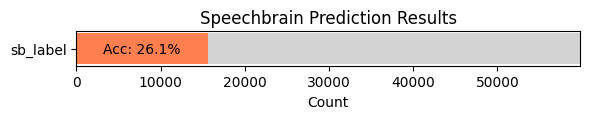

In [ ]:
fig, ax = plt.subplots(figsize=(6, 1.3))
plot_prediction_results(df, 'sb_label', False, True, 'False', 'True', 'Speechbrain Prediction Results', ax=ax)
plt.tight_layout()
plt.show()

**Speechbrain Analysis**

Overall low accuracy shows that the Speechbrain model is ineffective at distinguishing between reference and cloned

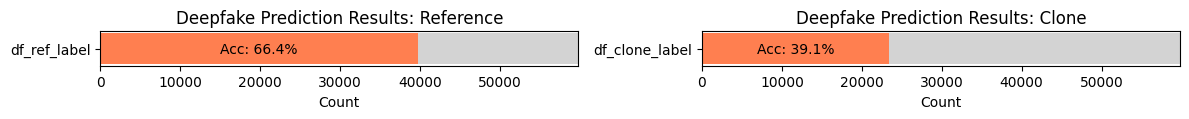

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 1.3))
plot_prediction_results(df, 'df_ref_label', 'Real', 'Fake', 'Real', 'Fake', 'Deepfake Prediction Results: Reference', ax=axes[0])
plot_prediction_results(df, 'df_clone_label', 'Fake', 'Real', 'Fake', 'Real', 'Deepfake Prediction Results: Clone', ax=axes[1])
plt.tight_layout()
plt.show()

**Deepfake Analysis**

- ACC - Reference only: 66.4%
- ACC - Clone only: 39.1%
- ACC - Overall: 52.75%

Overall accuracy is around 52.75% suggesting the AST model also has weakness. Reference accuracy is higher than clone but not perfect suggesting that model design is not well tuned for certain voices. Low clone accuracy suggests that model design is adversarially weak in relation to the TTS cloning.

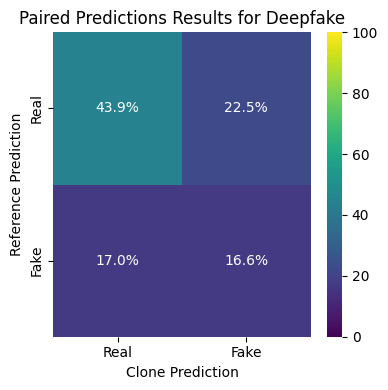

In [ ]:
cm = plot_combined_confusion_matrix(
    df,
    'df_ref_label',
    'df_clone_label',
    'Paired Predictions Results for Deepfake',
    labels=['Real', 'Fake'],
    show_percentages=True,
    cmap='viridis' # For alternative colormaps see Matplotlib
  )

**Deepfake: Paired Analysis**

Use the confusion results to analysis the predictions for each (REF, CLONE) data sample

- 13480 / 59810 (22.53%) had the correct predictions for each (REF, CLONE) pair
- 26254 / 59810 (43.89%) misclassifed both results as real suggesting these samples are particularly vulnerable
- 10175 / 59810 (17.01%) misclassified the wrong round where (REF=FAKE, CLONE=REAL). Could suggest the features of the reference voice are foreign to the detection models. May also suggest the CLONING in model is quite good at capturing real features
- 9901 / 59810 (16.55%) misclassified both results as fake suggesting model is hyper sensitive to certain samples



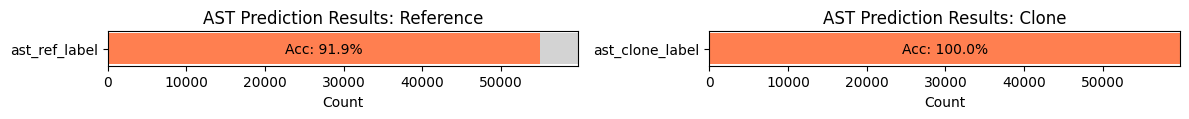

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 1.3))
plot_prediction_results(df, 'ast_ref_label', 'Real', 'Fake', 'Real', 'Fake', 'AST Prediction Results: Reference', ax=axes[0])
plot_prediction_results(df, 'ast_clone_label', 'Fake', 'Real', 'Fake', 'Real', 'AST Prediction Results: Clone', ax=axes[1])
plt.tight_layout()
plt.show()

**AST Analysis**

- ACC - Reference only: 91.9%
- ACC - Clone only: 100.0%
- ACC - Overall: 95.95%

Overall accuracy is around 95.95% suggesting the AST model is the strongest model by far. Cloning accuracy is perfect - no false negatives. However, lower reference accuracy shows model outputs false positives for certain samples, perhaps those it is less certain of. But false positives are better than false negatives.

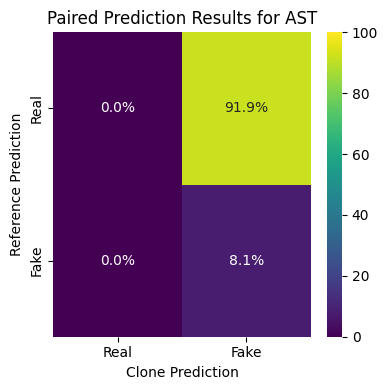

In [ ]:
cm = plot_combined_confusion_matrix(
    df,
    'ast_ref_label',
    'ast_clone_label',
    'Paired Prediction Results for AST',
    labels=['Real', 'Fake'],
    show_percentages=True,
    cmap='viridis'
  )

**AST: Paired Analysis**
- Majority of (REF, CLONE) pairs were correctly predicted.
- However, 4847 / 59810 (8.22%) of results were incorrectly mispredicted as clones suggesting there may be certain voices that the model cannot identify

In [ ]:

columns_to_describe = [col for col in df.columns if "score" in col]

# Display descriptive statistics
df[columns_to_describe].describe().T


,count,mean,std,min,25%,50%,75%,max
sb_score,59810.0,0.322448,0.111946,-0.139298,0.246029,0.323596,0.400689,0.698654
ast_ref_score,59810.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
ast_clone_score,59810.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
df_ref_score,59810.0,0.998143,0.015700,0.501863,0.999974,0.999983,0.999983,0.999983
df_clone_score,59810.0,0.997953,0.020225,0.501151,0.999946,0.999979,0.999983,0.999983


The table above shows the statistical measures for the scores of each model:
- AST outputs 1 for all preditions, meaning it predicts with high certainty.
- DF has a larger range but high mean and high median, suggesting there are a few outliers that it finds difficult.
- SB has a low mean and low median and a wide range suggesting its predictions are less secure.

### Distribution of Metadata Labels

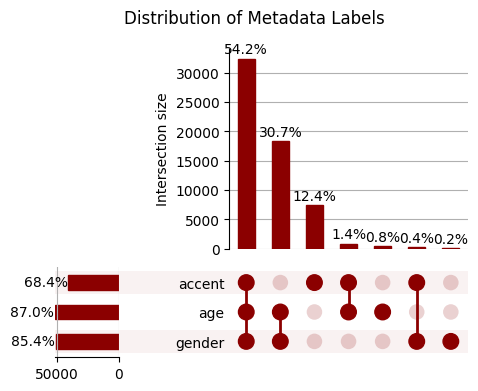

In [ ]:
plot_nan_distribution(df, ['gender', 'age', 'accent'], title='Distribution of Metadata Labels', sort_by='cardinality')

**Distribution of Metadata Labels**

Chart above shows interesting finds on the metadata that users were willing to provide. People were most willing to provide gender and age labels. However, accent was the most common choice if single label was provided. Interesting to consider how people feel about providing personal data in such open-source collection methods.

### By Gender

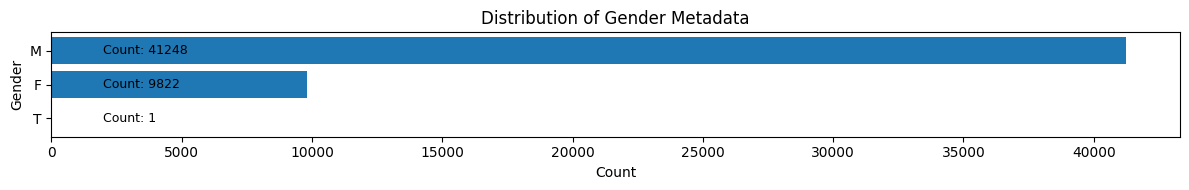

In [ ]:
plot_value_counts_bar(df, 'gender', title='Distribution of Gender Metadata', figsize=(12, 2), group_order=['M', 'F', 'T'])

**Distribution of Gender Labels**
- Predominantly male contributors
- Interesting note on the inclusion of Transgender but ambiguity surrounding MTF or FTM. Sample size here is too small for generalised predicitions

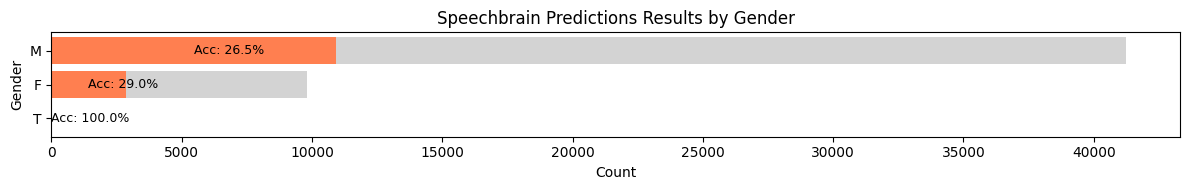

In [ ]:
fig, ax = plt.subplots(figsize=(12, 2))
plot_grouped_prediction_results(df, ax, group_col='gender', prediction_col='sb_label', correct_value=False, incorrect_value=True, title='Speechbrain Predictions Results by Gender', correct_color='coral', group_order = ['M', 'F', 'T'])
plt.tight_layout()
plt.show()

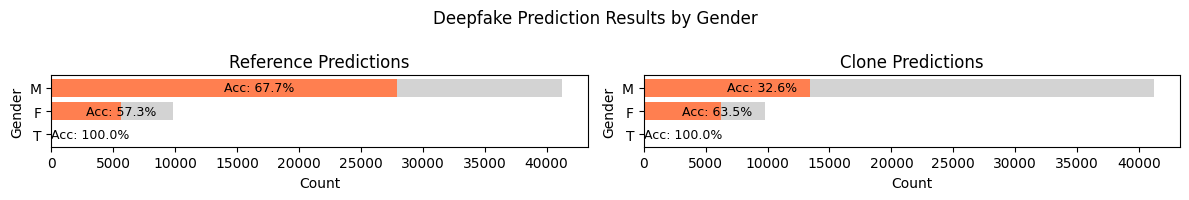

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 2))
plot_grouped_prediction_results(df, axes[0], group_col='gender', prediction_col='df_ref_label', correct_value='Real', incorrect_value='Fake', correct_label='Real', incorrect_label='Fake', title='Reference Predictions', group_order = ['M', 'F', 'T'])
plot_grouped_prediction_results(df, axes[1], group_col='gender', prediction_col='df_clone_label', correct_value='Fake', incorrect_value='Real', correct_label='Fake', incorrect_label='Real', title='Clone Predictions', group_order = ['M', 'F', 'T'])
plt.suptitle("Deepfake Prediction Results by Gender")
plt.tight_layout()
plt.show()

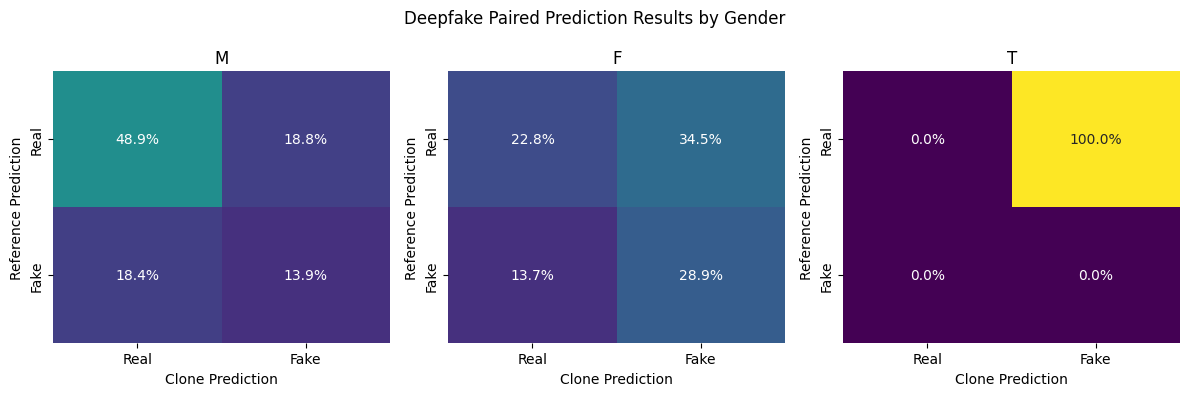

In [ ]:
plot_grouped_confusion_matrices(
    df,
    group_col='gender',
    col1='df_ref_label',
    col2='df_clone_label',
    title_prefix='Deepfake Paired Prediction Results by Gender',
    labels=['Real', 'Fake'],
    max_cols=4,
    show_percentages=True,
    group_order = ['M', 'F', 'T'],
    cmap = 'viridis'
)

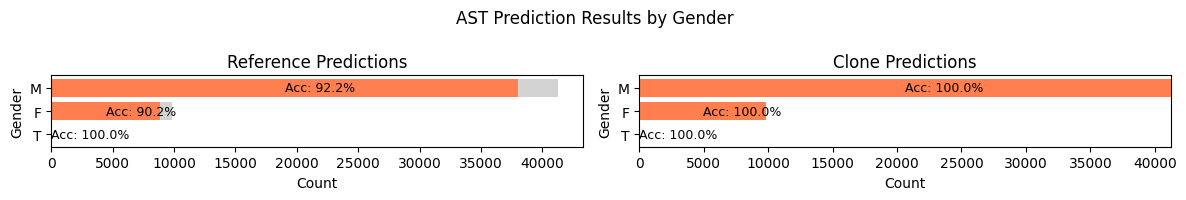

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 2))
group_order = ['M', 'F', 'T']
plot_grouped_prediction_results(df, axes[0], group_col='gender', prediction_col='ast_ref_label', correct_value='Real', incorrect_value='Fake', correct_label='Real', incorrect_label='Fake', title='Reference Predictions', group_order=group_order)
plot_grouped_prediction_results(df, axes[1], group_col='gender', prediction_col='ast_clone_label', correct_value='Fake', incorrect_value='Real', correct_label='Fake', incorrect_label='Real', title='Clone Predictions', group_order=group_order)
plt.suptitle("AST Prediction Results by Gender")
plt.tight_layout()
plt.show()


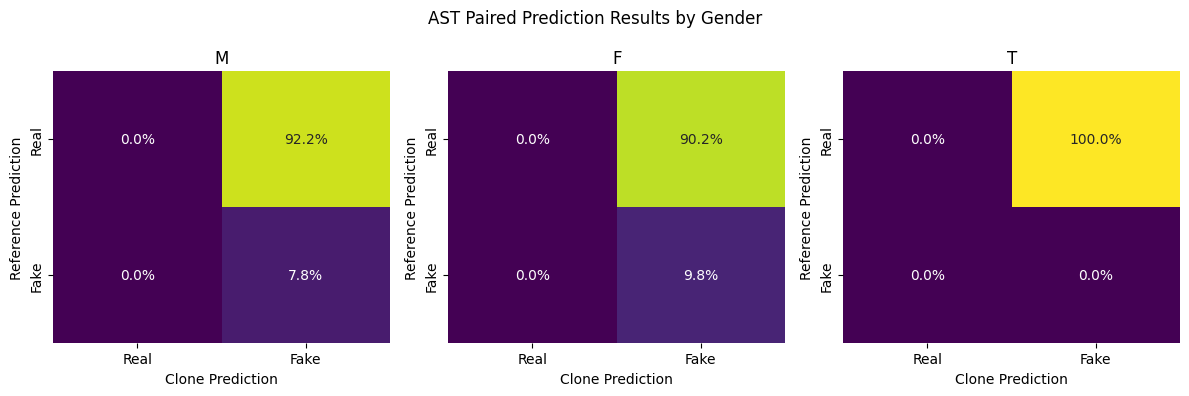

In [ ]:
plot_grouped_confusion_matrices(
    df,
    group_col='gender',
    col1='ast_ref_label',
    col2='ast_clone_label',
    title_prefix='AST Paired Prediction Results by Gender',
    labels=['Real', 'Fake'],
    show_percentages=True,
    group_order=group_order,
    cmap='viridis'
)

### By Age

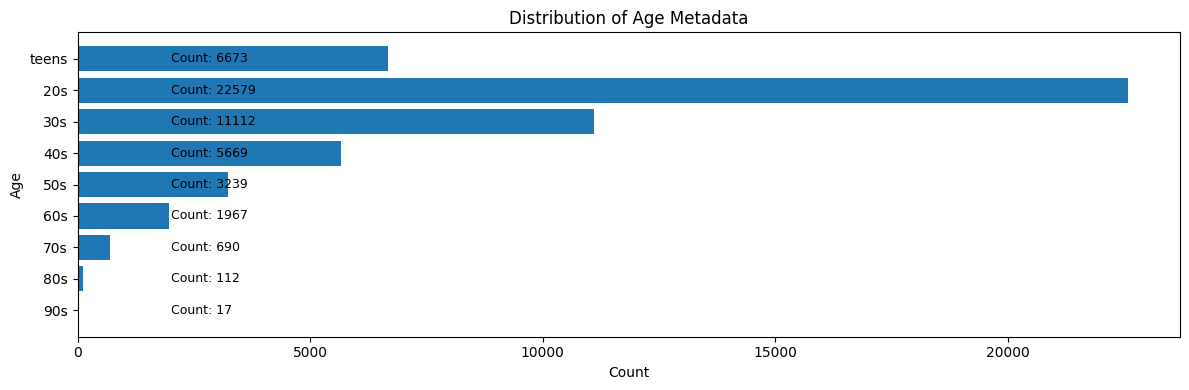

In [ ]:
group_order=['teens', '20s', '30s', '40s', '50s', '60s', '70s', '80s', '90s']
plot_value_counts_bar(df, 'age', title='Distribution of Age Metadata', figsize=(12, 4), group_order=group_order)

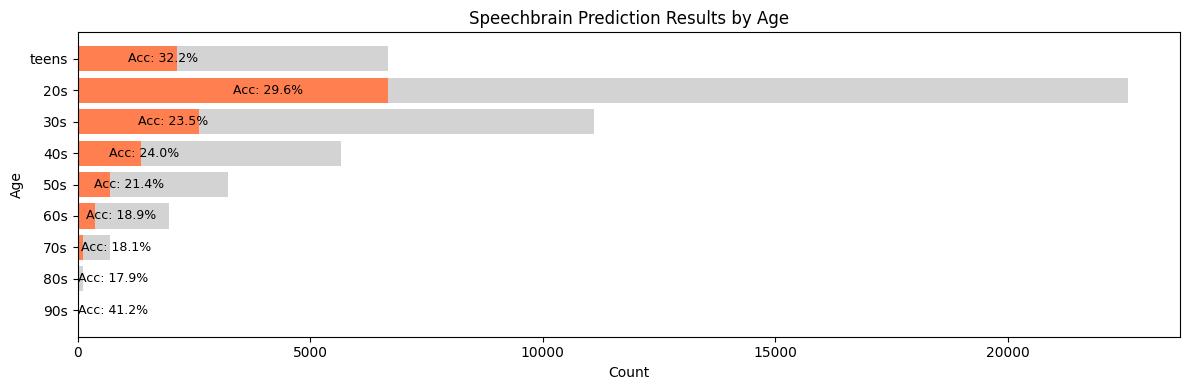

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
group_order=['teens', '20s', '30s', '40s', '50s', '60s', '70s', '80s', '90s']
plot_grouped_prediction_results(df, ax, group_col='age', prediction_col='sb_label', correct_value=False, incorrect_value=True, title='Speechbrain Prediction Results by Age', correct_color='coral', group_order = group_order)
plt.tight_layout()
plt.show()

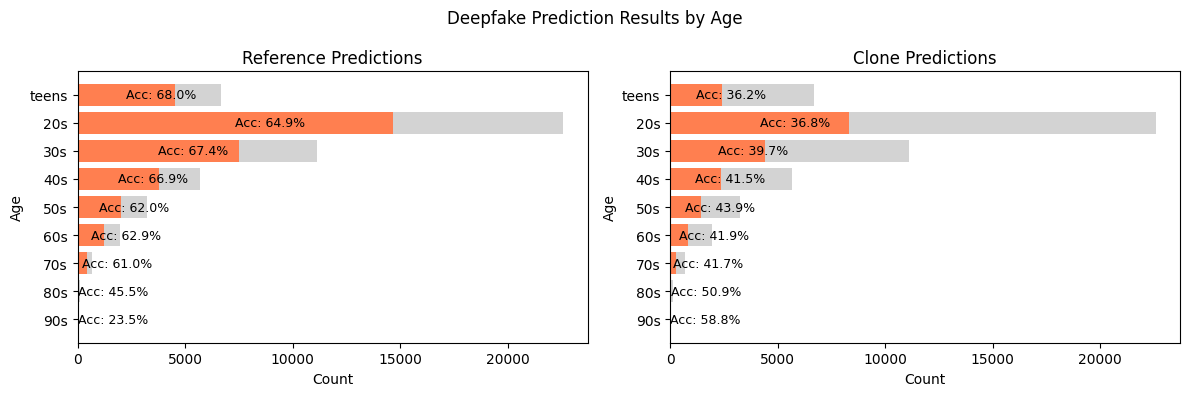

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
group_order=['teens', '20s', '30s', '40s', '50s', '60s', '70s', '80s', '90s']
plot_grouped_prediction_results(df, axes[0], group_col='age', prediction_col='df_ref_label', correct_value='Real', incorrect_value='Fake', correct_label='Real', incorrect_label='Fake', title='Reference Predictions', group_order=group_order)
plot_grouped_prediction_results(df, axes[1], group_col='age', prediction_col='df_clone_label', correct_value='Fake', incorrect_value='Real', correct_label='Fake', incorrect_label='Real', title='Clone Predictions', group_order=group_order)
plt.suptitle('Deepfake Prediction Results by Age')
plt.tight_layout()
plt.show()

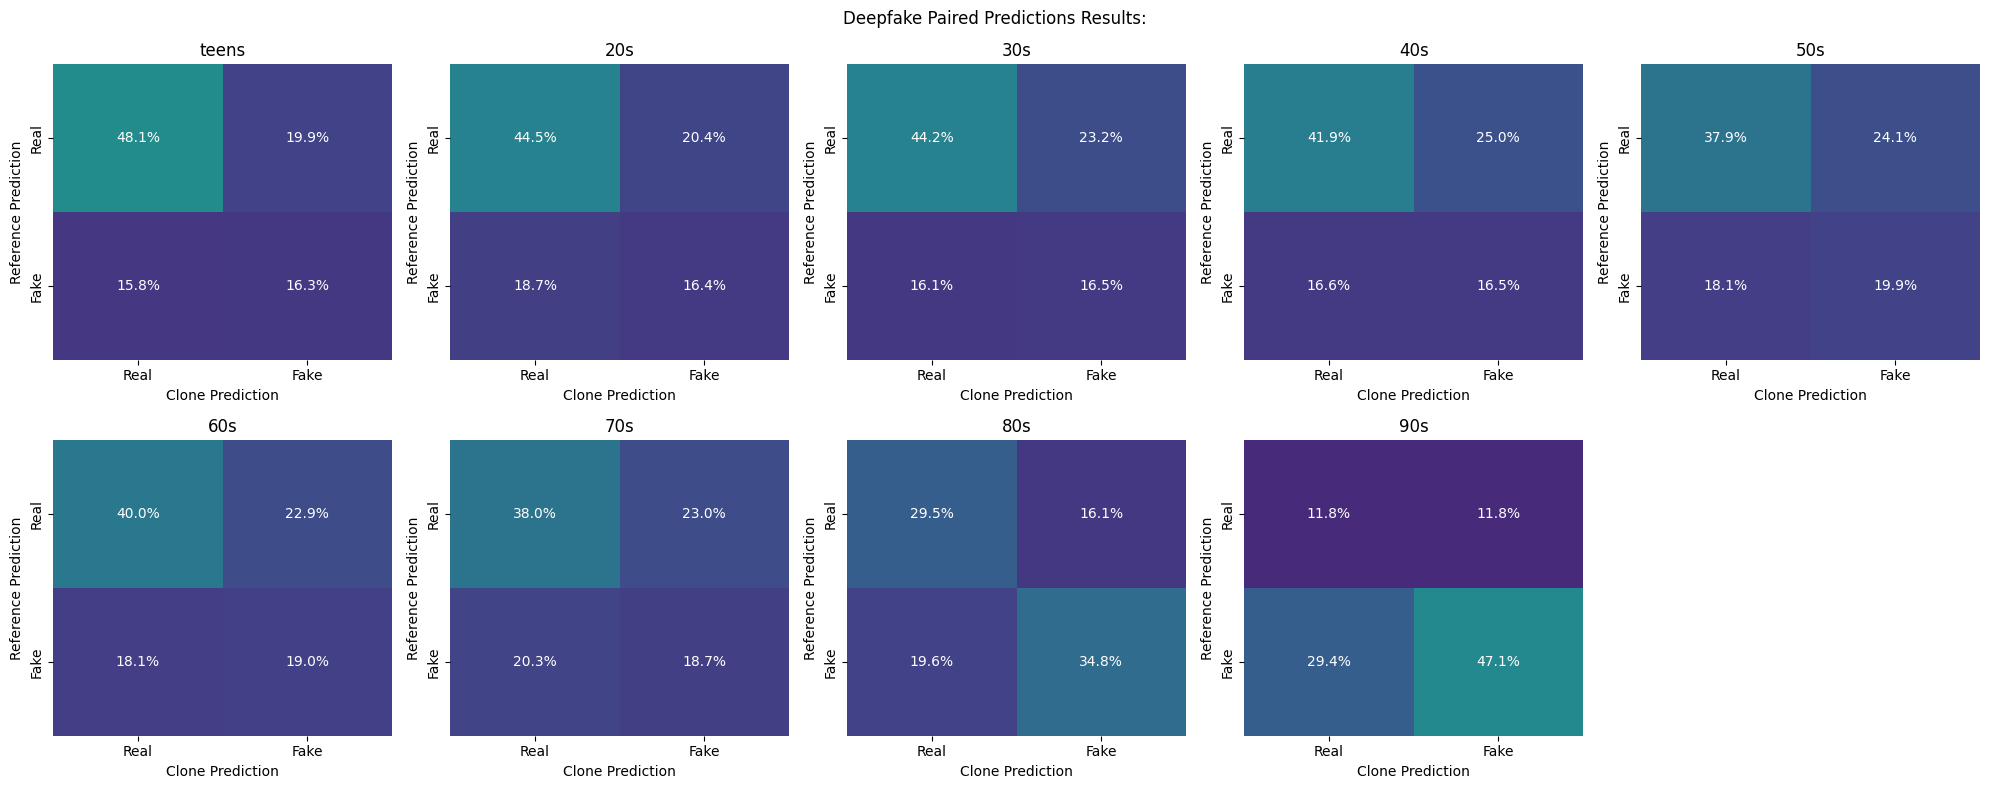

In [ ]:
group_order=['teens', '20s', '30s', '40s', '50s', '60s', '70s', '80s', '90s']
plot_grouped_confusion_matrices(
    df,
    group_col='age',
    col1='df_ref_label',
    col2='df_clone_label',
    title_prefix='Deepfake Paired Predictions Results:',
    labels=['Real', 'Fake'],
    max_cols=5,
    show_percentages=True,
    group_order=group_order,
    cmap='viridis',
)

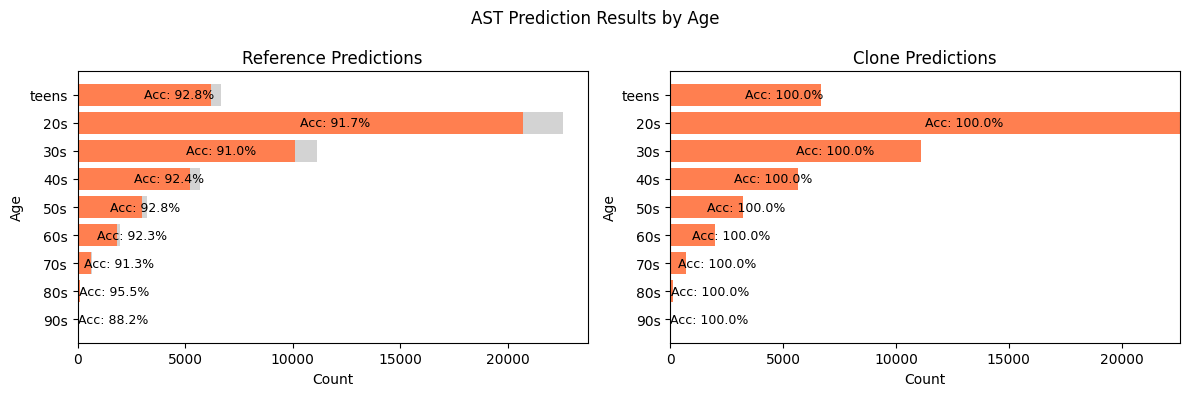

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
plot_grouped_prediction_results(df, axes[0], group_col='age', prediction_col='ast_ref_label', correct_value='Real', incorrect_value='Fake', correct_label='Real', incorrect_label='Fake', title='Reference Predictions', group_order=group_order)
plot_grouped_prediction_results(df, axes[1], group_col='age', prediction_col='ast_clone_label', correct_value='Fake', incorrect_value='Real', correct_label='Fake', incorrect_label='Real', title='Clone Predictions', group_order=group_order)
plt.suptitle("AST Prediction Results by Age")
plt.tight_layout()
plt.show()

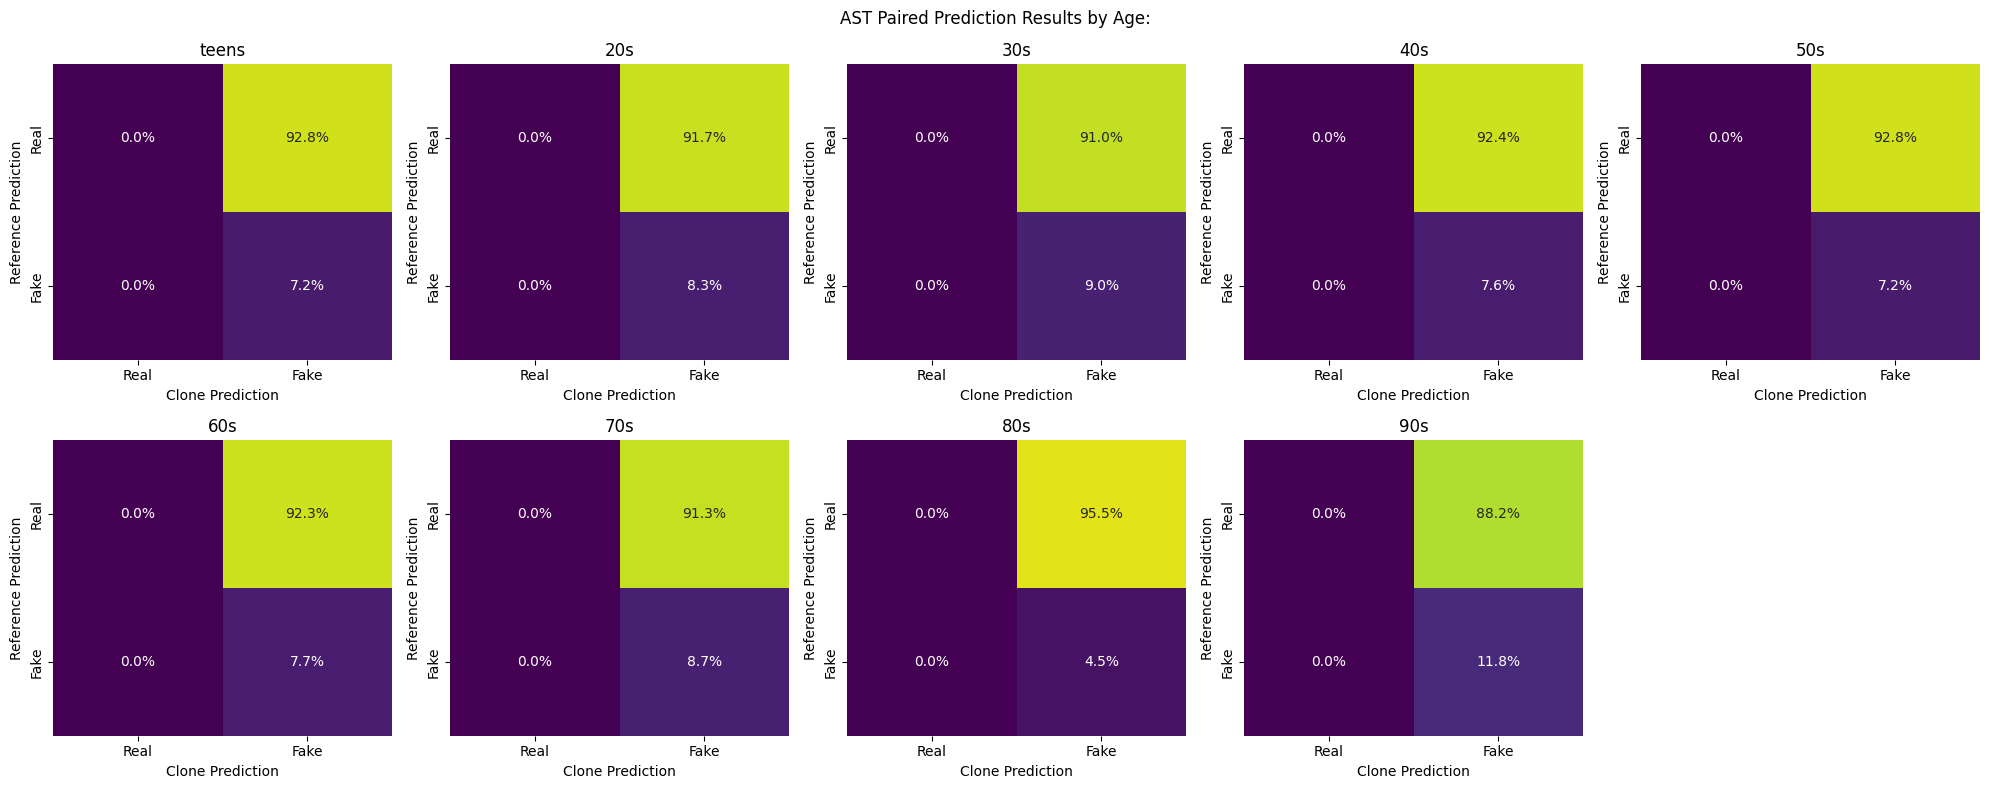

In [ ]:
group_order=['teens', '20s', '30s', '40s', '50s', '60s', '70s', '80s', '90s']
plot_grouped_confusion_matrices(
    df,
    group_col='age',
    col1='ast_ref_label',
    col2='ast_clone_label',
    title_prefix='AST Paired Prediction Results by Age:',
    labels=['Real', 'Fake'],
    max_cols=5,
    show_percentages=True,
    group_order=group_order,
    cmap='viridis'
)

### By Accent

Dropped 19050 samples with unknown accent_labels labels.


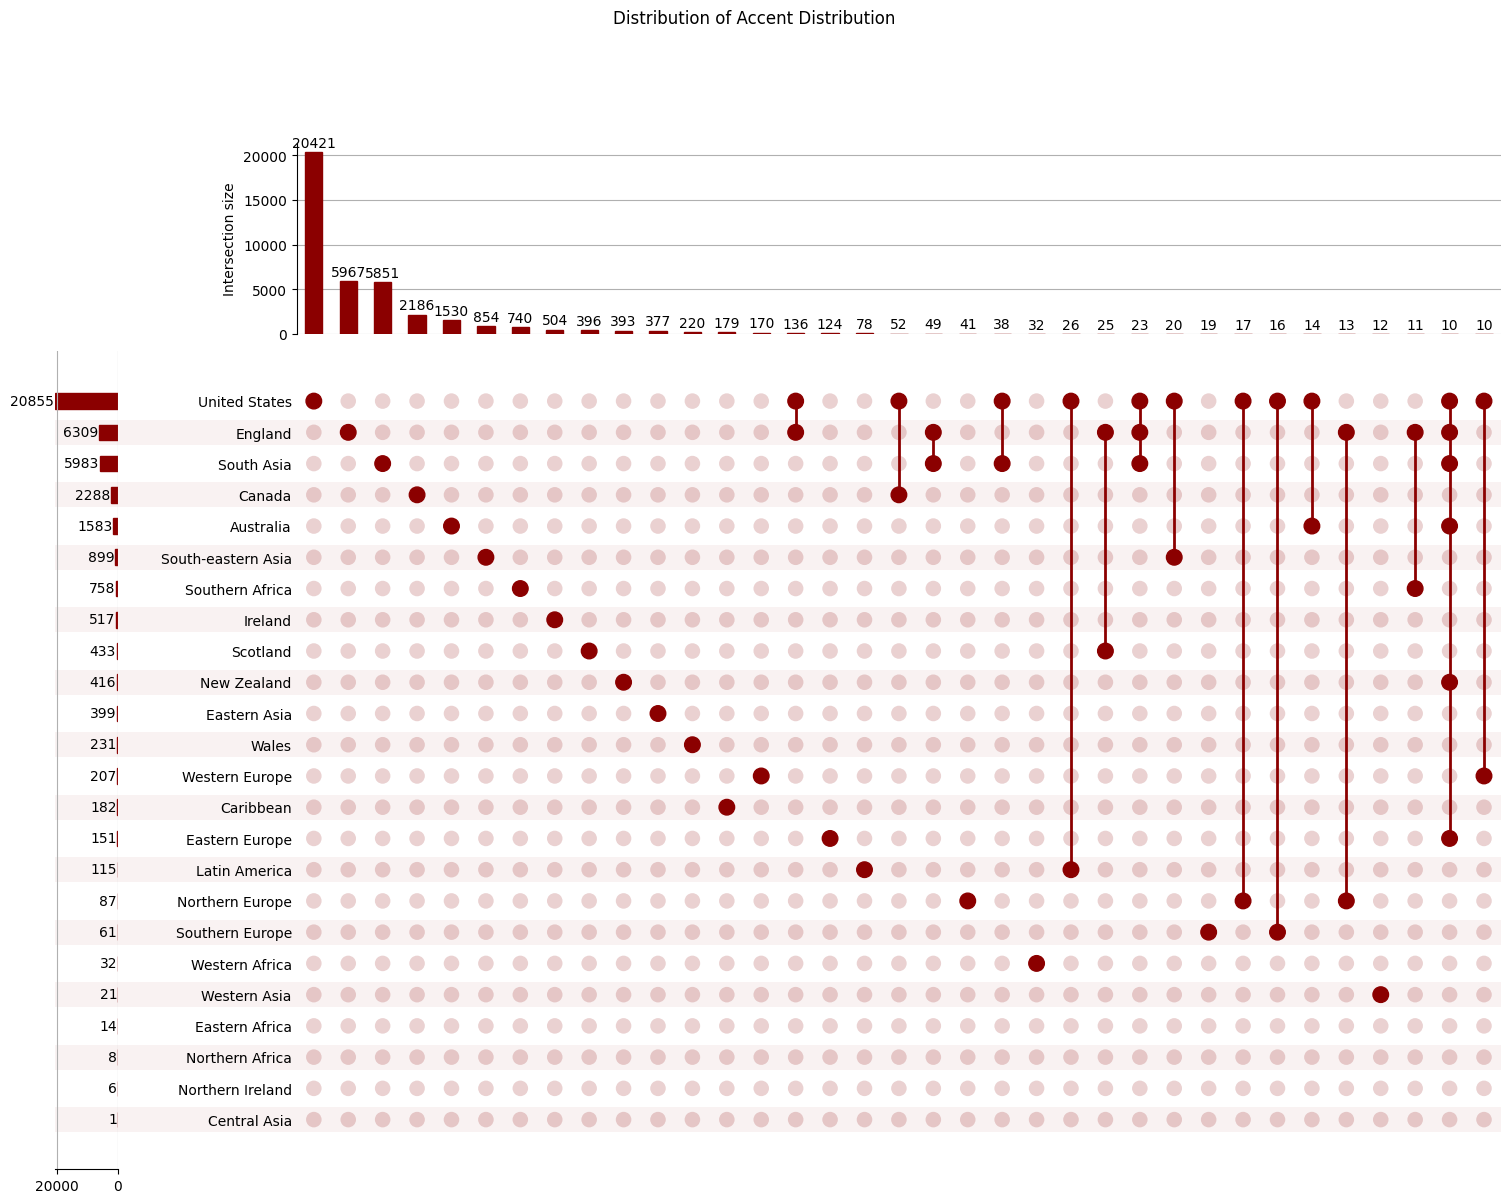

In [ ]:
plot_multilabel_distribution(results_path, 'accent_labels', 'Distribution of Accent Distribution')

[b)](#section3b) Standardize the format of prediction labels and gender metadata and extract word count

[c)](#sectoin3c) Extract geographic markers from accent metadata

In [ ]:
top_countries = [
    'United States',
    'England',
    'South Asia',
    'Canada',
    'Australia',
    'South-eastern Asia',
    'Southern Africa',
    'Ireland',
    'Scotland',
    'New Zealand',
    'Eastern Asia',
    'Wales',
]

In [ ]:
# df['top_accents'] = df['accent_labels'].apply(lambda x: str(x[0]) if isinstance(x, list) and len(x) == 1 and x[0] in top_countries else None)

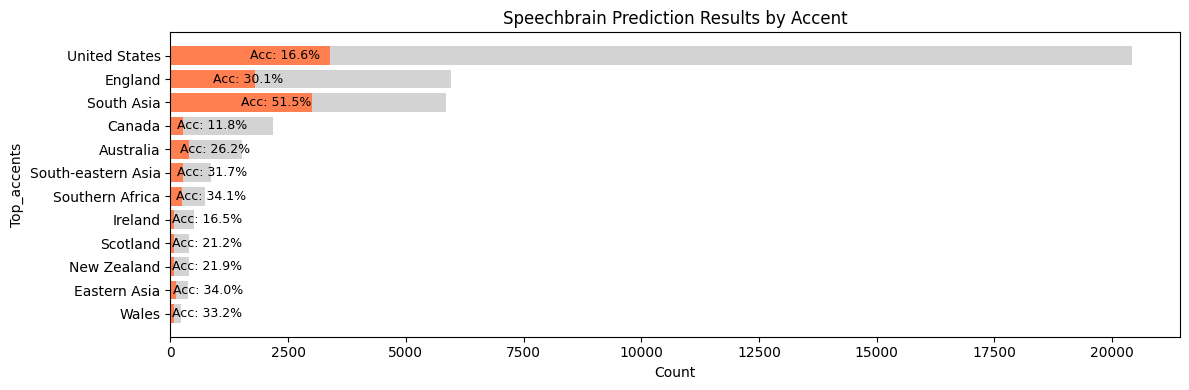

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_grouped_prediction_results(df, ax, group_col='top_accents', prediction_col='sb_label', title='Speechbrain Prediction Results by Accent', correct_color='coral', group_order=top_countries)
plt.tight_layout()
plt.show()

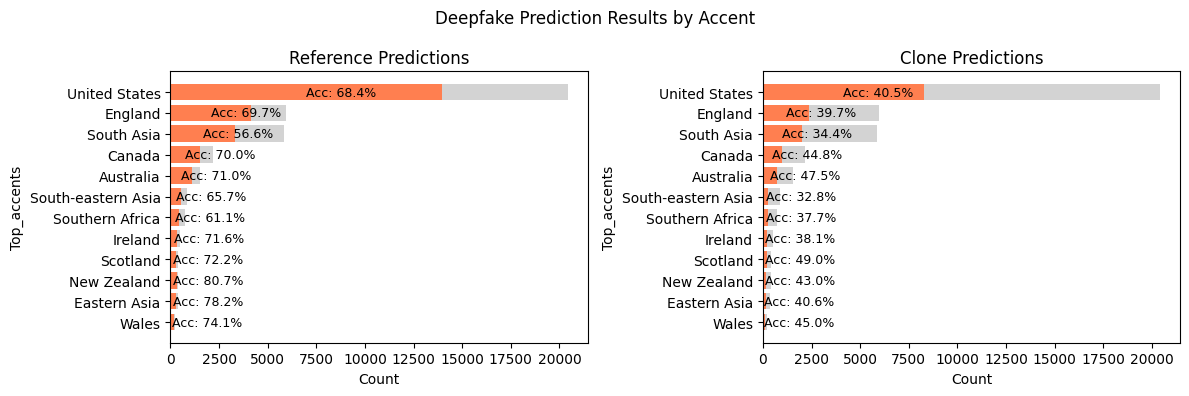

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
plot_grouped_prediction_results(df, axes[0], group_col='top_accents', prediction_col='df_ref_label', correct_value='Real', incorrect_value='Fake', correct_label='Real', incorrect_label='Fake', title='Reference Predictions', group_order=top_countries)
plot_grouped_prediction_results(df, axes[1], group_col='top_accents', prediction_col='df_clone_label', correct_value='Fake', incorrect_value='Real', correct_label='Fake', incorrect_label='Real', title='Clone Predictions', group_order=top_countries)
plt.suptitle('Deepfake Prediction Results by Accent')
plt.tight_layout()
plt.show()

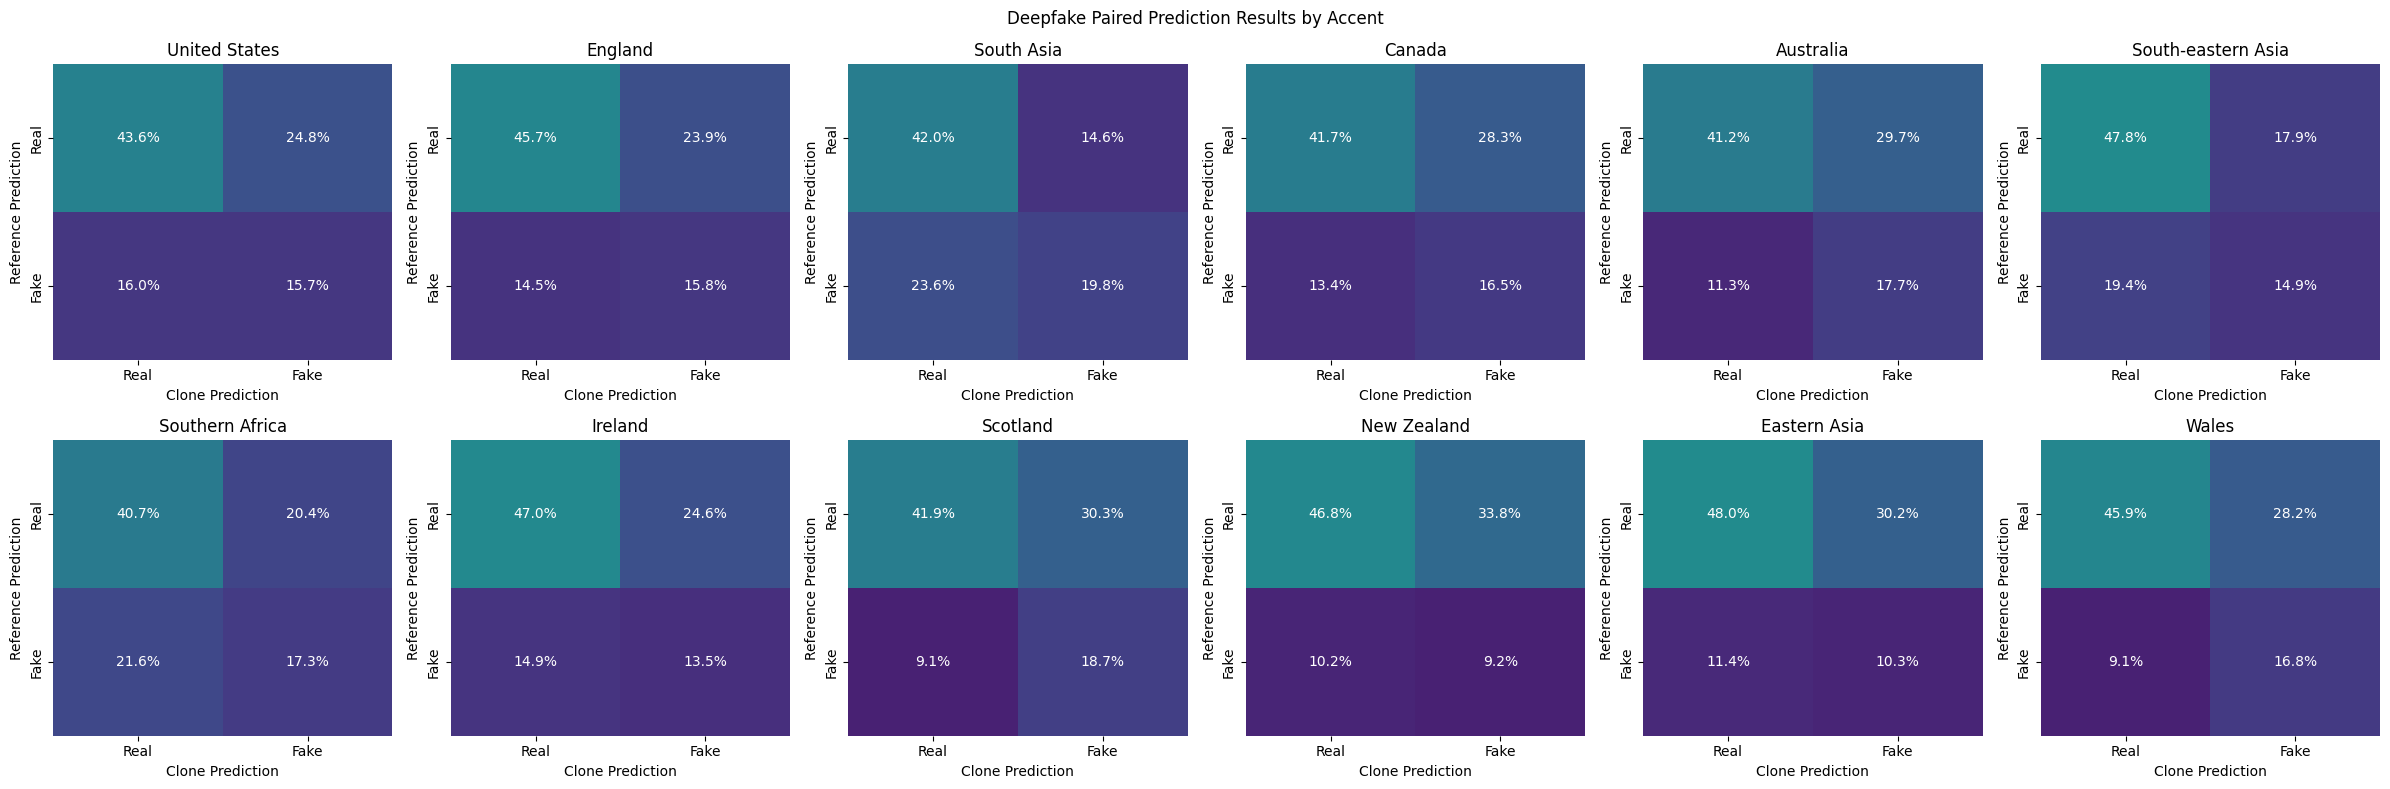

In [ ]:
plot_grouped_confusion_matrices(
    df,
    group_col='top_accents',
    col1='df_ref_label',
    col2='df_clone_label',
    title_prefix='Deepfake Paired Prediction Results by Accent',
    labels=['Real', 'Fake'],
    max_cols=6,
    show_percentages=True,
    cmap='viridis',
    group_order = top_countries
)

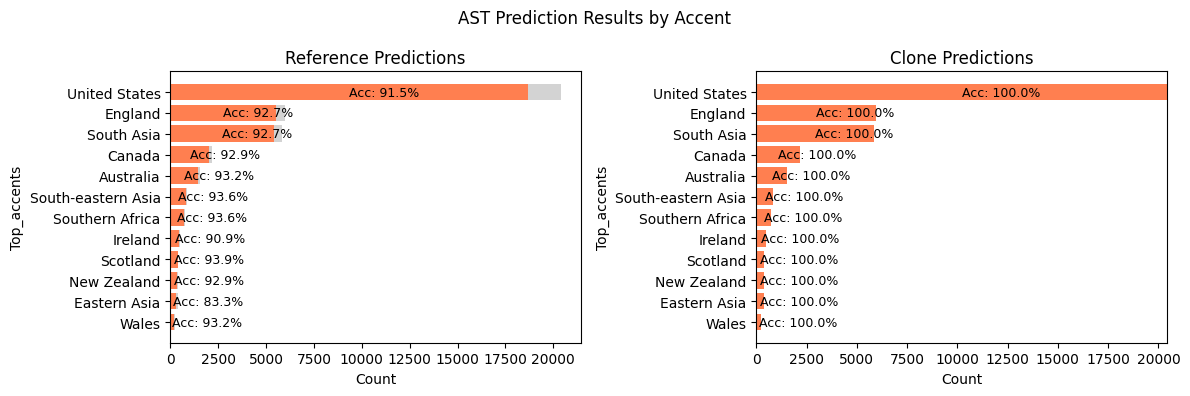

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
plot_grouped_prediction_results(df, axes[0], group_col='top_accents', prediction_col='ast_ref_label', correct_value='Real', incorrect_value='Fake', correct_label='Real', incorrect_label='Fake', title='Reference Predictions', group_order=top_countries)
plot_grouped_prediction_results(df, axes[1], group_col='top_accents', prediction_col='ast_clone_label', correct_value='Fake', incorrect_value='Real', correct_label='Fake', incorrect_label='Real', title='Clone Predictions', group_order=top_countries)
plt.suptitle("AST Prediction Results by Accent")
plt.tight_layout()
plt.show()

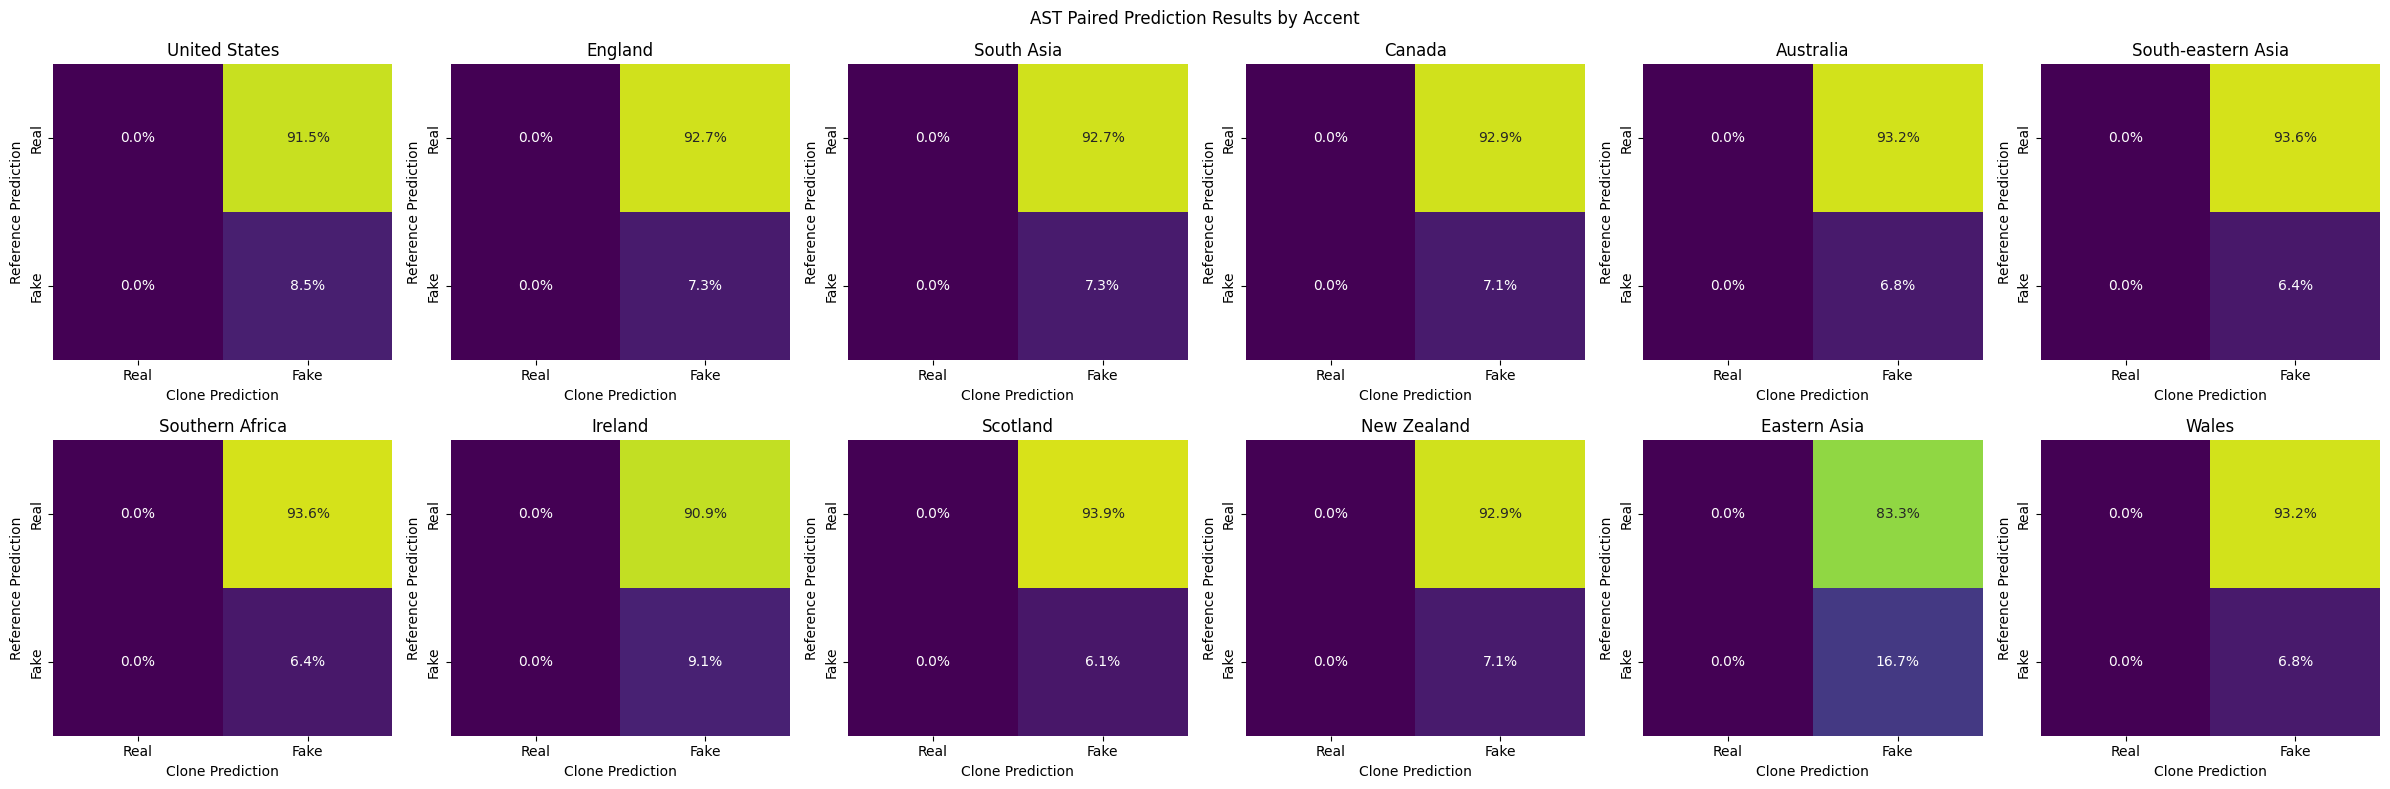

In [ ]:
plot_grouped_confusion_matrices(
    df,
    group_col='top_accents',
    col1='ast_ref_label',
    col2='ast_clone_label',
    title_prefix='AST Paired Prediction Results by Accent',
    labels=['Real', 'Fake'],
    max_cols=6,
    show_percentages=True,
    group_order = top_countries,
    cmap='viridis'
)